In [7]:
import sys
import time
import pathlib
cur_path = pathlib.Path().resolve().parent.absolute()
src_loc = cur_path.joinpath("src")
util_loc = src_loc.joinpath("utils")
sys.path.append(str(cur_path))
sys.path.append(str(src_loc))
sys.path.append(str(util_loc))

# 1 Load Data

### 1.1 Setup env and load packages

In [8]:
# load the libraries and initial settings
import os
import pathlib
import time
import datetime
import subprocess
import pyarrow as pa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
from pathlib import Path
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from src.conf import Conf
from src.utils.utils import elapsed_time, save_data, load_data
from src.utils.sql import sql
# Load configuration
confparam_path = cur_path.joinpath("src", "conf", "conf_dev.yml")
dataparam_path = cur_path.joinpath("src", "data", "ctp_dbt_model", "dbt_project.yml")
conf = Conf(confparam_path, dataparam_path )
project_start_time = time.time()

### 1.2 query data from EDH

#### 1.2.1 Query node features

In [9]:
# query for doctor&lawyer relationship

doc_lawyer_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_doctor_lawyer_pair_dbt
"""

# query for docotr&psych relationship

doc_psych_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_doctor_psych_pair_dbt
"""

# query for doctor&repairer relationship

doc_repair_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_doctor_repairer_pair_dbt
"""

# query for vehicle relationship

vehicle_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_vehicle_connection_dbt
"""

In [11]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_lawyer_df = sql( conf=conf, fn="get", sql=doc_lawyer_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.171
Total elapsed time: 0:0:13.352


In [12]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_psych_df = sql(conf=conf, fn="get", sql=doc_psych_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.758
Total elapsed time: 0:0:15.004


In [13]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_repair_df = sql(conf=conf, fn="get", sql=doc_repair_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.794
Total elapsed time: 0:0:16.998


In [14]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
vehicle_df = sql(conf=conf, fn="get", sql=vehicle_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.032
Total elapsed time: 0:0:19.365


#### 1.2.2 Query node features

In [15]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
node_query='SELECT * FROM dl_aai_sqd_claim.ctp_node_exposure_features'
node_df = sql(conf=conf, fn="get", sql=node_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:02.077
Total elapsed time: 0:0:22.928


In [16]:
node_df

,claim_number,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,...,self_employed_flag,pre_accident_weekly_earning,late_treatment_days,amt_fitness_certificate,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult,investigation_flag,fraud_flag
0,NWRTP2302537,1,2023-10-18,Closed,SOOJEONG SHIN,0432252085,4 / 118 Redfern St REDFERN NSW 2016,1,1,0.000,...,0,1224.220,13.000,2.000,0.000,0.000,0.000,0,0,0
1,NWRTP1802343,3,2020-12-09,Open,Harmony Machin,0414642901,15 / 6-12 Connelly St FLEMINGTON VIC 3031,0,0,1.000,...,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
2,NWRTP2202701,1,2022-12-15,Closed,Graham Martin,0402656145,1 Victoria St EGLINTON NSW 2795,1,0,1.000,...,0,3500.000,67.000,4.000,1.000,0.000,0.000,0,0,0
3,NWRND2300196,2,2023-09-28,Open,Cameron Gallagher,0435676130,2 Robertson Pl KINGSWOOD NSW 2340,1,0,1.000,...,0,834.160,208.000,11.000,0.000,0.000,0.000,0,0,0
4,NWRTP2102211,1,2021-10-01,Closed,Troy Smith,0475272611,55 Flakelar Cres TERRIGAL NSW 2260,0,0,0.000,...,0,0.000,NaN,NaN,NaN,NaN,0.000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36364,NWRTP2200471,1,2022-03-16,Open,Michael O'Brien,0400448309,191 Skye Point Rd COAL POINT NSW 2283,0,0,0.000,...,0,1.000,0.000,0.000,0.000,0.000,0.000,0,0,0
36365,NWRTP2100652,1,2021-03-18,Closed,Susanne Webster,0437495466,8 Pimelia Ct VOYAGER POINT NSW 2172,0,0,0.000,...,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
36366,NWRTP2501734,1,2025-06-30,Open,Gehad Gunaidi,0416019149,21 Barry Av MORTDALE NSW 2223,1,1,0.000,...,0,0.000,2.000,1.000,0.000,1.000,0.000,0,0,0
36367,NWRTP2200841,1,2022-05-09,Closed,Reece Pollock,0490060208,53 Figtree Boulevard Wadalba NSW 2259,0,0,0.000,...,0,0.000,NaN,NaN,NaN,NaN,NaN,0,0,0


In [17]:
# Check for duplicates based on claim number
print('*'*60)
print("check duplicates")
duplicates = node_df[node_df.duplicated(subset=['claim_number', 'claim_exposure_id'])]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(node_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 36369
Number of duplicates is 5071


### 1.3 create pa schema and save parquet

In [18]:
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_lawyer_df)
# save data 
save_data(doc_lawyer_df, conf.data_path, 'doc_lawyer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_psych_df)
# save data 
save_data(doc_psych_df, conf.data_path, 'doc_psych_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_repair_df)
# save data 
save_data(doc_repair_df, conf.data_path, 'doc_repair_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(vehicle_df)
# save data 
save_data(vehicle_df, conf.data_path, 'vehicle_connection_data', data_extension='parquet', schema=new_schema)


Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet


In [19]:
# save claim node data
new_schema = pa.Schema.from_pandas(node_df)
save_data(node_df, conf.data_path, 'node_feature', data_extension='parquet', schema=new_schema)

Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet


# 2 Data preprocessing

### 2.1 load data locally

In [20]:
import decimal
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder
import torch
from torch_geometric.data import Data
import numpy as np 
import pandas as pd
from torch_geometric.utils import to_networkx, degree
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities
from datetime import date

In [21]:
project_start_time = time.time()

print('*' * 60)
print("load data locally ...")

function_start_time = time.time()
doc_lawyer_df=load_data(conf.data_path, 'doc_lawyer_connection_data',  data_extension='parquet')
doc_psych_df=load_data(conf.data_path, 'doc_psych_connection_data',  data_extension='parquet')
doc_repair_df=load_data(conf.data_path, 'doc_repair_connection_data',  data_extension='parquet')
vehicle_df=load_data(conf.data_path, 'vehicle_connection_data',  data_extension='parquet')
node_df=load_data(conf.data_path, 'node_feature',  data_extension='parquet')

elapsed_time('load data', project_start_time, function_start_time)

************************************************************
load data locally ...
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet

Elapsed time (load data): 0:0:00.405
Total elapsed time: 0:0:00.406


In [22]:
node_df['investigation_flag'].value_counts()

0    36044
1      325
Name: investigation_flag, dtype: int64

### 2.2 Node features engineering 

In [23]:
# input_dataframe=merged_df.copy()
input_dataframe=node_df.copy()
input_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36369 entries, 0 to 36368
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   claim_number                        36369 non-null  object 
 1   claim_exposure_id                   36369 non-null  int64  
 2   claim_exposure_lodgement_date       36369 non-null  object 
 3   claim_exposure_status_name          36369 non-null  object 
 4   contact_full_name                   36369 non-null  object 
 5   fixed_contact_number                35571 non-null  object 
 6   full_address                        36351 non-null  object 
 7   not_fit_for_work_flag               36369 non-null  int64  
 8   off_work_minor_injury_flag          36369 non-null  int64  
 9   not_threshold_injury_flag           34787 non-null  float64
 10  days_of_minor_assess_to_lodgement   34787 non-null  float64
 11  suspacious_not_working_flag         36369

In [24]:
def data_transformation(input_dataframe):
        """
        Function to perform data preparation steps on the given model_data DataFrame.

        Args:
        - input_dataframe: DataFrame containing the data to be prepared

        Returns:
        - model_data: DataFrame with the prepared data including node features
        """

        # Remove duplicates from input dataframe
        input_dataframe = input_dataframe.drop_duplicates(subset=['claim_number','claim_exposure_id'], keep='first')

        # fill the missing value

        fill_zero_cols = [
                'not_fit_for_work_flag',
                'off_work_minor_injury_flag',
                'not_threshold_injury_flag',
                'days_of_minor_assess_to_lodgement',
                'suspacious_not_working_flag',
                'self_employed_flag',
                'pre_accident_weekly_earning',
                'late_treatment_days',
                'amt_fitness_certificate',
                'cof_holiday_weekend_flag',
                'cof_issue_to_received_over_2m_flag',
                'rejected_pay_over_8_flag',
                'gp05_pay_exceed_gp_consult'
        ]

        for x in fill_zero_cols:
                input_dataframe[x].fillna(0, inplace=True)

        # Column Selection
        # Numeric columns
        num_cols = [
                'days_of_minor_assess_to_lodgement',
                'pre_accident_weekly_earning',
                'amt_fitness_certificate',
                'late_treatment_days',
        ]
        #One hot encodin
        ohe_cols = [
                'not_fit_for_work_flag',
                'off_work_minor_injury_flag',
                'not_threshold_injury_flag',
                'suspacious_not_working_flag',
                'self_employed_flag',
                'cof_holiday_weekend_flag',
                'cof_issue_to_received_over_2m_flag',
                'rejected_pay_over_8_flag',
                'gp05_pay_exceed_gp_consult'
        ]
        #id_columns
        id_cols = [    
                'claim_number',
                'claim_exposure_id',
                'claim_exposure_lodgement_date',
                'claim_exposure_status_name',
                'contact_full_name',
                'fixed_contact_number',
                'full_address',
                'investigation_flag',
                'fraud_flag'
        ]

        features=  id_cols+ num_cols + ohe_cols
        df_node_feature = input_dataframe[features].copy()
        df_node_feature[ohe_cols]=df_node_feature[ohe_cols].astype(int)
        
        # df_node_id = input_dataframe[id_cols].copy()
        df_node_feature['claim_exposure_id']=  df_node_feature['claim_number'] + '_'+  df_node_feature['claim_exposure_id'].astype(str)
        df_node_feature.drop(columns=['claim_number'], inplace=True)
        df_node_feature.sort_values(by=['claim_exposure_lodgement_date','claim_exposure_id'], ascending=True, inplace=True)
        df_node_feature.reset_index(drop=True, inplace=True)

        return df_node_feature

In [25]:
# perform data processing and engineering
df_node_feature = data_transformation(input_dataframe)
df_node_feature

c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,pre_accident_weekly_earning,...,late_treatment_days,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult
0,NWRTP1700088_1,2018-01-02,Closed,KATIE CLIFFORD,0400020783,12 HARRISON STREET CARDIFF NSW 2285,0,0,81.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
1,NWRTP1700089_1,2018-01-02,Closed,TANIA RADOVIC,0432231500,34 WESTBROOK AVE WAHROONGA NSW 2076,0,0,72.000,229.280,...,10.000,1,1,0,0,0,0,0,0,0
2,NWRTP1800001_1,2018-01-02,Closed,Gloria Rudder,0499401788,2031 Willi Willi Rd TEMAGOG NSW 2440,0,0,73.000,0.000,...,7.000,1,0,1,1,0,0,0,0,0
3,NWRTP1800002_1,2018-01-02,Closed,JOSHUA FARR,0401579618,6 STOKE LANE CARCOAR NSW 2791,0,0,64.000,707.560,...,406.000,1,0,1,1,0,0,0,0,0
4,NWRTP1800003_1,2018-01-02,Closed,JUAN CABREJOS,0427494778,13 THE CRESCENT HELENSBURGH NSW 2508,0,0,66.000,0.000,...,0.000,0,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31293,NWRTP2502657_1,2025-09-25,Open,My Hoang,0411279665,152 Sackville St FAIRFIELD NSW 2165,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
31294,NWRTP2502658_1,2025-09-25,Open,Tess Walker,0400613000,6 Hilltop Gr CLIFTLEIGH NSW 2321,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
31295,NWRTP2502659_1,2025-09-25,Open,Rominder DODD,None,7 Alkoomie avenue Forestville NSW 2087,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
31296,NWRTP2502660_1,2025-09-25,Open,Fedoseeva Evgeniia,0490800862,1208 / 1 Australia Av SYDNEY OLYMPIC PARK NSW ...,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0


### 2.3 Build CTP Claim Network

In [26]:
with open(Path(conf.data_path+'/doctor_name_map_clustered.json'), 'r', encoding='utf-8') as f:
    doctor_map = json.load(f)
with open(Path(conf.data_path+'/lawyer_name_map_clustered.json'), 'r', encoding='utf-8') as f:
    lawyer_map = json.load(f)
doc_lawyer_df['doctor_contact_name'] = (
    doc_lawyer_df['doctor_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(doctor_map)
                                        .fillna(doc_lawyer_df['doctor_contact_name'])
)

doc_lawyer_df['lawyer_contact_name'] = (
    doc_lawyer_df['lawyer_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(lawyer_map)
                                        .fillna(doc_lawyer_df['lawyer_contact_name'])  # keep original if not in similar-only map
)
doc_lawyer_df 

,claim_number_1,claim_exposure_id_1,claim_number_2,claim_exposure_id_2,doctor_contact_number,doctor_contact_name,lawyer_contact_number,lawyer_contact_name
0,NWRTP1902154,1,NWRND2500048,1,0296007778,Australis Health Group Pty Ltd,0290590600,Alliance Compensation And Litigation Lawyers
1,NWRTP1801548,1,NWRTP2001179,1,0288490102,Sebastian Calvache-rubio,0292991424,P K Simpson And Co
2,NWRTP2302992,2,NWRTP2302427,1,0282111100,J Medical And Cosmetic Centre,0282624736,Littles Lawyers
3,NWRTP1801548,1,NWRTP1802105,1,0288490102,Sebastian Calvache-rubio,0292991424,P K Simpson And Co
4,NWRTP2101670,1,NWRTP2500153,1,0288490102,Eric Lim,0402614477,Benefit Legal Lawyers Pty Ltd
...,...,...,...,...,...,...,...,...
16659,NWRTP2303143,2,NWRTP1800362,1,0287899008,Angela Lam,0468331681,Stephen Young Lawyers
16660,NWRTP1900033,1,NWRTP1801583,1,1300375426,Yasmin Khan,0297273780,State Law Group
16661,NWRTP2102302,1,NWRTP2302992,2,0282111100,Hajeong Lee,0282624734,Littles Lawyers
16662,NWRTP2100241,1,NWRTP1902590,1,0287899008,Angela Lam,0296350889,Stephen Young Lawyers


In [27]:
doc_freq=doc_lawyer_df['doctor_contact_name'].value_counts()
doc_lawyer_df['doc_freq']= doc_lawyer_df['doctor_contact_name'].map(doc_freq)
doc_lawyer_df['doc_weight'] = 1.0 / doc_lawyer_df['doc_freq']**2

lawyer_freq=doc_lawyer_df['lawyer_contact_name'].value_counts()
doc_lawyer_df['lawyer_freq']= doc_lawyer_df['lawyer_contact_name'].map(lawyer_freq)
doc_lawyer_df['lawyer_weight'] = 1.0 / doc_lawyer_df['lawyer_freq']**2

# doc_lawyer_df = doc_lawyer_df[(doc_lawyer_df['doc_weight']>0.01) & (doc_lawyer_df['lawyer_weight']>0.01)]

doc_lawyer_df['weight'] = doc_lawyer_df['doc_weight'] + doc_lawyer_df['lawyer_weight']

# Create the combined “party_name” column
doc_lawyer_df['party_name'] = doc_lawyer_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, lawyer: {row['lawyer_contact_name']})",
    axis=1
)

# Create the combined “contact_number” column
doc_lawyer_df['party_contact_number'] = doc_lawyer_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_number']}, lawyer: {row['lawyer_contact_number']})",
    axis=1
)

doc_lawyer_df['claim_exposure_id_1']= doc_lawyer_df['claim_number_1'] + '_'+ doc_lawyer_df['claim_exposure_id_1'].astype(str)
doc_lawyer_df['claim_exposure_id_2']= doc_lawyer_df['claim_number_2'] + '_'+ doc_lawyer_df['claim_exposure_id_2'].astype(str)

# Drop the now-unneeded originals
doc_lawyer_df = doc_lawyer_df.drop(columns=[
    'claim_number_1',
    'claim_number_2',
    'doctor_contact_name',
    'lawyer_contact_name',
    'doctor_contact_number',
    'lawyer_contact_number',
    'doc_freq',
    'lawyer_freq',
    'doc_weight',   
    'lawyer_weight'
]).reset_index(drop=True)


doc_lawyer_df

,claim_exposure_id_1,claim_exposure_id_2,weight,party_name,party_contact_number
0,NWRTP1902154_1,NWRND2500048_1,0.000,"(doctor: Australis Health Group Pty Ltd, lawye...","(doctor: 0296007778, lawyer: 0290590600)"
1,NWRTP1801548_1,NWRTP2001179_1,0.000,"(doctor: Sebastian Calvache-rubio, lawyer: P K...","(doctor: 0288490102, lawyer: 0292991424)"
2,NWRTP2302992_2,NWRTP2302427_1,0.000,"(doctor: J Medical And Cosmetic Centre, lawyer...","(doctor: 0282111100, lawyer: 0282624736)"
3,NWRTP1801548_1,NWRTP1802105_1,0.000,"(doctor: Sebastian Calvache-rubio, lawyer: P K...","(doctor: 0288490102, lawyer: 0292991424)"
4,NWRTP2101670_1,NWRTP2500153_1,0.000,"(doctor: Eric Lim, lawyer: Benefit Legal Lawye...","(doctor: 0288490102, lawyer: 0402614477)"
...,...,...,...,...,...
16659,NWRTP2303143_2,NWRTP1800362_1,0.000,"(doctor: Angela Lam, lawyer: Stephen Young Law...","(doctor: 0287899008, lawyer: 0468331681)"
16660,NWRTP1900033_1,NWRTP1801583_1,0.000,"(doctor: Yasmin Khan, lawyer: State Law Group)","(doctor: 1300375426, lawyer: 0297273780)"
16661,NWRTP2102302_1,NWRTP2302992_2,0.000,"(doctor: Hajeong Lee, lawyer: Littles Lawyers)","(doctor: 0282111100, lawyer: 0282624734)"
16662,NWRTP2100241_1,NWRTP1902590_1,0.000,"(doctor: Angela Lam, lawyer: Stephen Young Law...","(doctor: 0287899008, lawyer: 0296350889)"


In [28]:
doc_psych_df['doctor_contact_name'] = (
    doc_psych_df['doctor_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(doctor_map)
                                        .fillna(doc_psych_df['doctor_contact_name'])
)

doc_freq=doc_psych_df['doctor_contact_name'].value_counts()
doc_psych_df['doc_freq']= doc_psych_df['doctor_contact_name'].map(doc_freq)
doc_psych_df['doc_weight'] = 1.0 / doc_psych_df['doc_freq']**2

psych_freq=doc_psych_df['psych_contact_name'].value_counts()
doc_psych_df['psych_freq']= doc_psych_df['psych_contact_name'].map(psych_freq)
doc_psych_df['psych_weight'] = 1.0 / doc_psych_df['psych_freq']**2

# doc_psych_df = doc_psych_df[(doc_psych_df['doc_weight']>0.01) & (doc_psych_df['psych_weight']>0.01)]

doc_psych_df['weight'] = doc_psych_df['doc_weight'] + doc_psych_df['psych_weight']

doc_psych_df['party_name'] = doc_psych_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, psych: {row['psych_contact_name']})",
    axis=1
)
doc_psych_df['party_contact_number'] = doc_psych_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_number']}, psych: {row['psych_contact_number']})",
    axis=1
)

doc_psych_df['claim_exposure_id_1']= doc_psych_df['claim_number_1'] + '_'+ doc_psych_df['claim_exposure_id_1'].astype(str)
doc_psych_df['claim_exposure_id_2']= doc_psych_df['claim_number_2'] + '_'+ doc_psych_df['claim_exposure_id_2'].astype(str)

doc_psych_df = doc_psych_df.drop(columns=[
    'claim_number_1',
    'claim_number_2',
    'doctor_contact_name',
    'psych_contact_name',
    'doctor_contact_number',
    'psych_contact_number',
    'doc_freq',
    'psych_freq',       
    'doc_weight',
    'psych_weight'
]).reset_index(drop=True)

doc_psych_df

,claim_exposure_id_1,claim_exposure_id_2,weight,party_name,party_contact_number
0,NWRTP2400728_1,NWRTP2301351_1,0.035,"(doctor: Rubina Siddiqui, psych: Peter Kim)","(doctor: 0288490102, psych: 0478242998)"
1,NWRTP2400728_1,NWRTP2300210_1,0.023,"(doctor: Taslima Sultana, psych: Peter Kim)","(doctor: 0288490102, psych: 0478242998)"
2,NWRTP1901119_1,NWRTP1901119_2,0.083,"(doctor: J Medical And Cosmetic Centre, psych:...","(doctor: 0282111100, psych: 0282111100)"
3,NWRTP2300210_1,NWRTP1902478_1,0.001,"(doctor: Eric Lim, psych: Insightful Mind)","(doctor: None, psych: 0478242998)"
4,NWRTP2301351_1,NWRTP2201899_1,1.020,"(doctor: Alan Dao, psych: Shannon Mair)","(doctor: None, psych: None)"
...,...,...,...,...,...
149,NWRTP1800228_5,NWRTP1802493_1,0.004,"(doctor: Eric Lim, psych: Erin Carmody)","(doctor: 0288490102, psych: None)"
150,NWRTP2002025_1,NWRTP2000366_1,0.065,"(doctor: S Calvache-R, psych: Workers Doctors)","(doctor: 0288490102, psych: 0288490102)"
151,NWRTP2400728_1,NWRTP2403533_1,0.012,"(doctor: Morgan Mo, psych: Peter Kim)","(doctor: None, psych: 0478242998)"
152,NWRTP2002025_1,NWRTP1900984_1,0.003,"(doctor: Eric Lim, psych: Workers Doctors)","(doctor: 0288490102, psych: 0288490102)"


In [29]:
doc_repair_df['doctor_contact_name'] = (
    doc_repair_df['doctor_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(doctor_map)
                                        .fillna(doc_repair_df['doctor_contact_name'])
)

doc_freq=doc_repair_df['doctor_contact_name'].value_counts()
doc_repair_df['doc_freq']= doc_repair_df['doctor_contact_name'].map(doc_freq)
doc_repair_df['doc_weight'] = 1.0 / doc_repair_df['doc_freq']**2

repair_freq=doc_repair_df['repairer_name'].value_counts()
doc_repair_df['repair_freq']= doc_repair_df['repairer_name'].map(repair_freq)
doc_repair_df['repair_weight'] = 1.0 / doc_repair_df['repair_freq']**2

# doc_repair_df = doc_repair_df[(doc_repair_df['doc_weight']>0.01) & (doc_repair_df['repair_weight']>0.01)]

doc_repair_df['weight'] = doc_repair_df['doc_weight'] + doc_repair_df['repair_weight']


doc_repair_df['party_name'] = doc_repair_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, repairer_name: {row['repairer_name']})",
    axis=1
)

doc_repair_df.rename(
    columns={
        'doctor_contact_number': 'party_contact_number'
    },
    inplace=True
)

doc_repair_df['claim_exposure_id_1']= doc_repair_df['claim_number_1'] + '_'+ doc_repair_df['claim_exposure_id_1'].astype(str)
doc_repair_df['claim_exposure_id_2']= doc_repair_df['claim_number_2'] + '_'+ doc_repair_df['claim_exposure_id_2'].astype(str)

doc_repair_df = doc_repair_df.drop(columns=[
    'claim_number_1',
    'claim_number_2', 
    'doctor_contact_name',      
    'repairer_name',
    'doc_freq',
    'repair_freq',  
    'doc_weight',
    'repair_weight'
])


doc_repair_df

,claim_exposure_id_1,claim_exposure_id_2,party_contact_number,weight,party_name
0,NWRTP2100326_1,NWRTP2101583_1,0259431000,1.250,"(doctor: Georgina Macdonald, repairer_name: SN..."
1,NWRTP2300840_3,NWRTP2302635_1,0264919222,0.278,"(doctor: J Thornton, repairer_name: MGM PANEL ..."
2,NWRTP2302010_1,NWRTP2400207_1,0255242000,1.111,"(doctor: Unknown Romero, repairer_name: NATURE..."
3,NWRTP1901439_1,NWRTP2000392_1,0243041333,1.002,"(doctor: Sameh Shabayek, repairer_name: ADAMS ..."
4,NWRTP2400645_1,NWRTP2100273_1,0260584444,0.278,"(doctor: Albury Wodonga Health, repairer_name:..."
...,...,...,...,...,...
61,NWRTP2201871_1,NWRTP2200532_1,0243202111,0.113,"(doctor: Jeremy Ratcliffe, repairer_name: ADAM..."
62,NWRTP2201871_1,NWRTP2102094_1,0243202111,0.113,"(doctor: Jeremy Ratcliffe, repairer_name: ADAM..."
63,NWRTP2401878_1,NWRTP2100273_1,0260584444,0.278,"(doctor: Lehaslenie Thirukuman, repairer_name:..."
64,NWRTP2501123_1,NWRTP2201317_1,0259431000,1.250,"(doctor: Morgan Prince, repairer_name: GRAEME ..."


In [30]:
vehicle_df.rename(
    columns={
        'rego_number': 'party_name'
    },
    inplace=True
)
vehicle_df['claim_exposure_id_1']= vehicle_df['claim_number_1'] + '_'+ vehicle_df['claim_exposure_id_1'].astype(str)
vehicle_df['claim_exposure_id_2']= vehicle_df['claim_number_2'] + '_'+ vehicle_df['claim_exposure_id_2'].astype(str)

party_freq = vehicle_df['party_name'].value_counts()
vehicle_df['freq_party'] = vehicle_df['party_name'].map(party_freq)
vehicle_df['weight'] = 1.0 / vehicle_df['freq_party']**2

# vehicle_df = vehicle_df[(vehicle_df['weight']>0.01)]

# Drop the now-unneeded originals
vehicle_df = vehicle_df.drop(columns=[
    'claim_number_1',
    'claim_number_2',
    'freq_party'
])

vehicle_df


,claim_exposure_id_1,claim_exposure_id_2,party_name,weight
0,NWRTP2101876_1,NWRTP1903325_1,EBU48,0.250
1,NWRTP2302768_1,DPNTP2400009_1,VET50,0.028
2,NWRTP2001181_1,NWRTP2101666_1,MPU86,0.250
3,NWRTP1802217_1,NWRTP1802218_1,NWX87,0.250
4,DPNTP2400010_1,NWRTP2403493_1,FPM47,0.250
...,...,...,...,...
127,NWRTP2101919_1,NWRTP2101556_1,DSM023,0.250
128,NWRTP1900035_1,NWRTP1900048_1,COL71Z,0.250
129,NWRTP2102179_1,DPNTP2400005_1,CY13BV,0.250
130,DPNTP2400009_1,DPNTP2400008_1,VET50,0.028


In [31]:
# indicate connection/relationship type for further use
doc_lawyer_df['connection_type'] = 'doc_lawyer'
doc_psych_df['connection_type'] = 'doc_psych'
doc_repair_df['connection_type'] = 'doc_repair'
vehicle_df['connection_type'] = 'vehicle'

In [32]:
# concatnate all different type of edges
edges_all= pd.concat(
    [doc_lawyer_df, doc_psych_df, doc_repair_df, vehicle_df],
    ignore_index=True,
    sort=False  
)

In [33]:
#For undirected graphs, sort the node IDs in each edge to treat (u, v) and (v, u) as the same
edges_all['edge']=edges_all.apply(lambda row: tuple([row['claim_exposure_id_1'], row['claim_exposure_id_2']]), axis=1)
# Efficiently create unordered pair columns without apply
# edges_all['id_min'] = np.minimum(edges_all['claim_exposure_id_1'], edges_all['claim_exposure_id_2'])
# edges_all['id_max'] = np.maximum(edges_all['claim_exposure_id_1'], edges_all['claim_exposure_id_2'])

In [34]:
edges_grouped = edges_all.groupby(['edge']).agg({
    'weight': 'sum',
    'connection_type': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
    'party_name': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
    'party_contact_number': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
}).reset_index()

#Split 'edge' back into 'source' and 'target'
edges_grouped[['claim_exposure_id_1', 'claim_exposure_id_2']] = pd.DataFrame(edges_grouped['edge'].tolist(), index=edges_grouped.index)
edges_grouped = edges_grouped.drop(columns='edge')
edges_grouped

,weight,connection_type,party_name,party_contact_number,claim_exposure_id_1,claim_exposure_id_2
0,0.250,[vehicle],[CZD04E],[],DPNTP2400001_1,NWRTP2402003_2
1,0.250,[vehicle],[EEC01V],[],DPNTP2400002_1,NWRTP2402179_2
2,0.250,[vehicle],[EUS59E],[],DPNTP2400003_1,NWRTP2400461_1
3,0.250,[vehicle],[BNE97B],[],DPNTP2400004_1,NWRTP2402845_1
4,0.250,[vehicle],[CY13BV],[],DPNTP2400005_1,NWRTP2102179_1
...,...,...,...,...,...,...
16019,0.260,[doc_lawyer],"[(doctor: Morgan Go, lawyer: Ton Legal)]","[(doctor: 0288490102, lawyer: 0297256889)]",NWRTP2502600_1,NWRTP2501190_1
16020,0.048,[doc_lawyer],"[(doctor: Peng Wang, lawyer: Blue Cosmos Pty L...","[(doctor: 0294152899, lawyer: 0402830453)]",NWRTP2502608_1,NWRTP2501379_1
16021,0.048,[doc_lawyer],"[(doctor: Peng Wang, lawyer: Blue Cosmos Pty L...","[(doctor: 0294152899, lawyer: 0402830453)]",NWRTP2502608_1,NWRTP2502610_1
16022,0.048,[doc_lawyer],"[(doctor: Peng Wang, lawyer: Blue Cosmos Pty L...","[(doctor: 0294152899, lawyer: 0402830453)]",NWRTP2502610_1,NWRTP2501379_1


In [35]:
# Create a mapping from node IDs to indices, including all nodes from df_node_features
# Extract node IDs from node features
feature_node_ids = set(df_node_feature['claim_exposure_id'])

# Extract node IDs from edges
edge_node_ids = set(edges_grouped['claim_exposure_id_1']).union(edges_grouped['claim_exposure_id_2'])

if edge_node_ids.issubset(feature_node_ids):
    print("All edge_node_ids are in feature_node_ids.")
else:
    missing_nodes = edge_node_ids - feature_node_ids
    print("Nodes in edge_node_ids but not in feature_node_ids:")
    print(missing_nodes)
    # now filter edges_grouped in-place (or assign to a new DF)
    edges_grouped = edges_grouped[
    edges_grouped['claim_exposure_id_1'].isin(feature_node_ids) &
    edges_grouped['claim_exposure_id_2'].isin(feature_node_ids)
        ].reset_index(drop=True)



All edge_node_ids are in feature_node_ids.


In [31]:
# # Filter out rows where 'source' or 'target' is in the exclusion set
# edges_grouped = edges_grouped[
#     ~edges_grouped['claim_exposure_id_1'].isin(missing_nodes) &
#     ~edges_grouped['claim_exposure_id_2'].isin(missing_nodes)
# ]

In [36]:
# Extract node IDs from edges
edge_node_ids = set(edges_grouped['claim_exposure_id_1']).union(edges_grouped['claim_exposure_id_2'])

# Extract node IDs from node features
feature_node_ids = df_node_feature['claim_exposure_id'].tolist()

if edge_node_ids.issubset(feature_node_ids):
    print("All edge_node_ids are in feature_node_ids.")


# Create mapping from node IDs to indices
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(feature_node_ids)}

All edge_node_ids are in feature_node_ids.


In [37]:
# Map claim number to indices in edges
edges_grouped['source_idx'] = edges_grouped['claim_exposure_id_1'].map(node_id_to_idx)
edges_grouped['target_idx'] = edges_grouped['claim_exposure_id_2'].map(node_id_to_idx)
# Prepare node features, including nodes without edges
df_node_feature['node_idx'] = df_node_feature['claim_exposure_id'].map(node_id_to_idx)


all_nodes_df = df_node_feature.sort_values('node_idx').reset_index(drop=True).set_index('node_idx')
all_nodes_df

,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,pre_accident_weekly_earning,...,late_treatment_days,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult
node_idx,,,,,,,,,,,,,,,,,,,,,
0,NWRTP1700088_1,2018-01-02,Closed,KATIE CLIFFORD,0400020783,12 HARRISON STREET CARDIFF NSW 2285,0,0,81.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
1,NWRTP1700089_1,2018-01-02,Closed,TANIA RADOVIC,0432231500,34 WESTBROOK AVE WAHROONGA NSW 2076,0,0,72.000,229.280,...,10.000,1,1,0,0,0,0,0,0,0
2,NWRTP1800001_1,2018-01-02,Closed,Gloria Rudder,0499401788,2031 Willi Willi Rd TEMAGOG NSW 2440,0,0,73.000,0.000,...,7.000,1,0,1,1,0,0,0,0,0
3,NWRTP1800002_1,2018-01-02,Closed,JOSHUA FARR,0401579618,6 STOKE LANE CARCOAR NSW 2791,0,0,64.000,707.560,...,406.000,1,0,1,1,0,0,0,0,0
4,NWRTP1800003_1,2018-01-02,Closed,JUAN CABREJOS,0427494778,13 THE CRESCENT HELENSBURGH NSW 2508,0,0,66.000,0.000,...,0.000,0,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31293,NWRTP2502657_1,2025-09-25,Open,My Hoang,0411279665,152 Sackville St FAIRFIELD NSW 2165,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
31294,NWRTP2502658_1,2025-09-25,Open,Tess Walker,0400613000,6 Hilltop Gr CLIFTLEIGH NSW 2321,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
31295,NWRTP2502659_1,2025-09-25,Open,Rominder DODD,None,7 Alkoomie avenue Forestville NSW 2087,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0


In [38]:

id_cols = [    
        'claim_exposure_id',
        'claim_exposure_lodgement_date',
        'claim_exposure_status_name',
        'contact_full_name',
        'fixed_contact_number',
        'full_address',
        'node_idx',
        'investigation_flag',
        'fraud_flag'
]
feature_cols=df_node_feature.columns.drop(id_cols)
feature_cols

Index(['days_of_minor_assess_to_lodgement', 'pre_accident_weekly_earning',
       'amt_fitness_certificate', 'late_treatment_days',
       'not_fit_for_work_flag', 'off_work_minor_injury_flag',
       'not_threshold_injury_flag', 'suspacious_not_working_flag',
       'self_employed_flag', 'cof_holiday_weekend_flag',
       'cof_issue_to_received_over_2m_flag', 'rejected_pay_over_8_flag',
       'gp05_pay_exceed_gp_consult'],
      dtype='object')

In [39]:
# Extract node features as a tensor
x = torch.tensor(all_nodes_df[feature_cols].values, dtype=torch.float)
# Create edge_index tensor
edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)
# edge_index = to_undirected(edge_index)

# Create edge_weight tensor
edge_weight = torch.tensor(edges_grouped['weight'].values, dtype=torch.float)
# Create investigation label tensor
y = torch.tensor(all_nodes_df['investigation_flag'].values, dtype=torch.long)

C:\Users\s745998\AppData\Local\Temp\ipykernel_35232\3453500741.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)


In [40]:
# Create PyG data object as CTP claim network
data = Data(x=x, edge_index=edge_index, edge_weight=edge_weight,y=y)
data

Data(x=[31298, 13], edge_index=[2, 16024], y=[31298], edge_weight=[16024])

In [41]:
from torch_geometric.utils import is_undirected
#validate undirected graph
is_undirected(data.edge_index)

True

In [42]:
# Filepath to save the data object
graph_path = os.path.join(conf.data_path, 'ctp_pyg_data.pt')

torch.save(data, graph_path)

# save node data 
new_schema = pa.Schema.from_pandas(all_nodes_df)
save_data(all_nodes_df, conf.data_path, 'node_features', data_extension='parquet', schema=new_schema)

# save edge data 
new_schema = pa.Schema.from_pandas(edges_grouped)
save_data(edges_grouped, conf.data_path, 'edge_features', data_extension='parquet', schema=new_schema)



Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_features.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\edge_features.parquet


### 2.4 Visualize the Network

In [43]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [44]:
# Load the data object
graph_path = os.path.join(conf.data_path, 'ctp_pyg_data.pt')
# data=torch.load(graph_path)

# all_nodes_df=load_data(conf.data_path, 'node_features',  data_extension='parquet')
# edges_grouped=load_data(conf.data_path, 'edge_features',  data_extension='parquet')

In [45]:
# # Convert PyG object to networkx data object
# G = to_networkx(data, node_attrs=['x', 'y'], edge_attrs=['edge_weight'], to_undirected=True)
G = to_networkx(data, to_undirected=True, edge_attrs=['edge_weight'],node_attrs=['x'])
# Add claim_number as node attribute in networkx graph G
num_nodes_org = G.number_of_nodes()
num_edges_org = G.number_of_edges()
print(f"Number of nodes: {num_nodes_org}")
print(f"Number of edges: {num_edges_org}")

Number of nodes: 31298
Number of edges: 8012


In [46]:
nx.set_node_attributes(G, all_nodes_df['claim_exposure_id'].to_dict(), 'claim_exposure_id')
nx.set_node_attributes(G, all_nodes_df['claim_exposure_lodgement_date'].to_dict(), 'claim_exposure_lodgement_date')
nx.set_node_attributes(G, all_nodes_df['claim_exposure_status_name'].to_dict(), 'claim_exposure_status_name')
nx.set_node_attributes(G, all_nodes_df['contact_full_name'].to_dict(), 'contact_full_name')
nx.set_node_attributes(G, all_nodes_df['fixed_contact_number'].to_dict(), 'fixed_contact_number')
nx.set_node_attributes(G, all_nodes_df['full_address'].to_dict(), 'full_address')
nx.set_node_attributes(G, all_nodes_df['investigation_flag'].to_dict(), 'investigation_flag')
nx.set_node_attributes(G, all_nodes_df['fraud_flag'].to_dict(), 'fraud_flag')

In [47]:
G.remove_nodes_from(list(nx.isolates(G)))

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 2380
Number of edges: 8012


In [48]:
node_percentage=num_nodes/num_nodes_org
edge_percentage=num_edges/num_edges_org

print('The percentage of remaining nodes is {:.2%}, and the percentage of remaining edges is {:.2%}'.format(
    node_percentage, edge_percentage))

The percentage of remaining nodes is 7.60%, and the percentage of remaining edges is 100.00%


In [49]:
for _, row in edges_grouped.iterrows():
    source_idx = row['source_idx']
    target_idx = row['target_idx']

    if G.has_edge(source_idx, target_idx):
            G.edges[source_idx, target_idx]['connection_type'] = row['connection_type']
            G.edges[source_idx, target_idx]['party_name'] = row['party_name']
            G.edges[source_idx, target_idx]['party_contact_number'] = row['party_contact_number']

In [50]:
type(edges_grouped['connection_type'][16023])

list

In [ ]:
def visualize_G(G):
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Node colours (unchanged) ---
    node_colors = [
        'red' if data.get('y') == 1 else 'skyblue'
        for _, data in G.nodes(data=True)
    ]

    # --- Build edge labels (unchanged) ---
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        parts = []
        if 'edge_weight' in data:
            parts.append(f"W: {data['edge_weight']}")
        if 'connection_type' in data:
            ct = data['connection_type']
            if isinstance(ct, (list, tuple, set)):
                parts.append("Type: " + ", ".join(map(str, ct)))
            else:
                parts.append("Type: " + str(ct))
        edge_labels[(u, v)] = "\n".join(parts)

    # --- Determine unique connection types (flatten sets/lists) ---
    conn_types = set()
    for _, _, data in G.edges(data=True):
        ct = data.get('connection_type')

        if isinstance(ct, (list, tuple, set)):
            for t in ct:
                conn_types.add(t)
        elif ct is not None:
            conn_types.add(ct)

    # --- Assign each type a colour from tab10 ---
    cmap = plt.get_cmap('tab10')
    type_to_color = {
        ct: cmap(i % cmap.N)
        for i, ct in enumerate(sorted(conn_types))
    }
    default_edge_color = 'grey'

    # --- Build edge-colour list (pick first type if multiple) ---
    edge_colors = []
    for _, _, data in G.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)) and len(ct) > 0:
            # pick the first element in the iterable
            key = next(iter(ct))
            edge_colors.append(type_to_color.get(key, default_edge_color))
        elif ct is not None:
            edge_colors.append(type_to_color.get(ct, default_edge_color))
        else:
            edge_colors.append(default_edge_color)

    # --- Plot ---
    pos = nx.random_layout(G)
    plt.figure(figsize=(10, 7))
    nx.draw(
        G, pos,
        with_labels=False,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=400,
    )
    # nx.draw_networkx_edge_labels(
    #     G, pos,
    #     edge_labels=edge_labels,
    #     font_size=6,
    #     label_pos=0.5
    # )
    nx.draw_networkx_labels(
        G, pos,
        labels={n: d.get('claim_exposure_id', str(n)) for n, d in G.nodes(data=True)},
        font_size=6
    )

    # --- Legend for connection types ---
    for ct, col in type_to_color.items():
        plt.plot([], [], color=col, label=str(ct))
    # plt.legend(title="Connection Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title('Graph with Edge Colours by Connection Type')
    plt.tight_layout()
    plt.show()


In [149]:
def visualize_G(G):
    import matplotlib.pyplot as plt
    import networkx as nx
    from matplotlib.lines import Line2D

    # --- Visualisation-only copy (remove isolates) ---
    G_vis = G.subgraph([n for n, deg in G.degree() if deg > 0]).copy()

    # --- Node colours based on investigation_flag ---
    node_colors = [
        'red' if data.get('investigation_flag') == 1 else 'skyblue'
        for _, data in G_vis.nodes(data=True)
    ]

    # --- Plot ---
    pos = nx.random_layout(G_vis)
    plt.figure(figsize=(10, 7))

    nx.draw(
        G_vis,
        pos,
        with_labels=False,
        node_color=node_colors,
        node_size=600,
    )

    # --- Labels (without claim_exposure_id) ---
    nx.draw_networkx_labels(
        G_vis,
        pos,
        labels={n: str(n) for n in G_vis.nodes()},
        font_size=6
    )

    # ✅ --- Custom Legend ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label='Investigated',
               markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w',
               label='Non-Investigated',
               markerfacecolor='skyblue', markersize=10)
    ]


    plt.legend(
        handles=legend_elements,
        title="Investigation Status",
        fontsize=14,        # ✅ legend label size
        title_fontsize=16,  # ✅ legend title size
        bbox_to_anchor=(0.75, 1.1),
        loc='upper left'
    )


    plt.title('IAG claim exposure graph',fontsize=18)
    plt.tight_layout()
    plt.show()


In [133]:

# Get nodes that have at least one neighbour (degree > 0)
nodes_with_neighbours = [n for n, deg in G.degree() if deg > 4]

# Create a subgraph containing only those nodes
G = G.subgraph(nodes_with_neighbours).copy()

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

In [134]:
import random
# Define the number of nodes to sample
num_nodes_to_sample = 100  # Adjust based on your requirements

# Randomly sample nodes
sampled_nodes = random.sample(list(G.nodes()), min(num_nodes_to_sample, num_nodes))

# Create a subgraph with the sampled nodes
G_sub = G.subgraph(sampled_nodes)

In [135]:
num_nodes = G_sub.number_of_nodes()
num_edges = G_sub.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 100
Number of edges: 158


C:\Users\s745998\AppData\Local\Temp\ipykernel_35232\3762787592.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


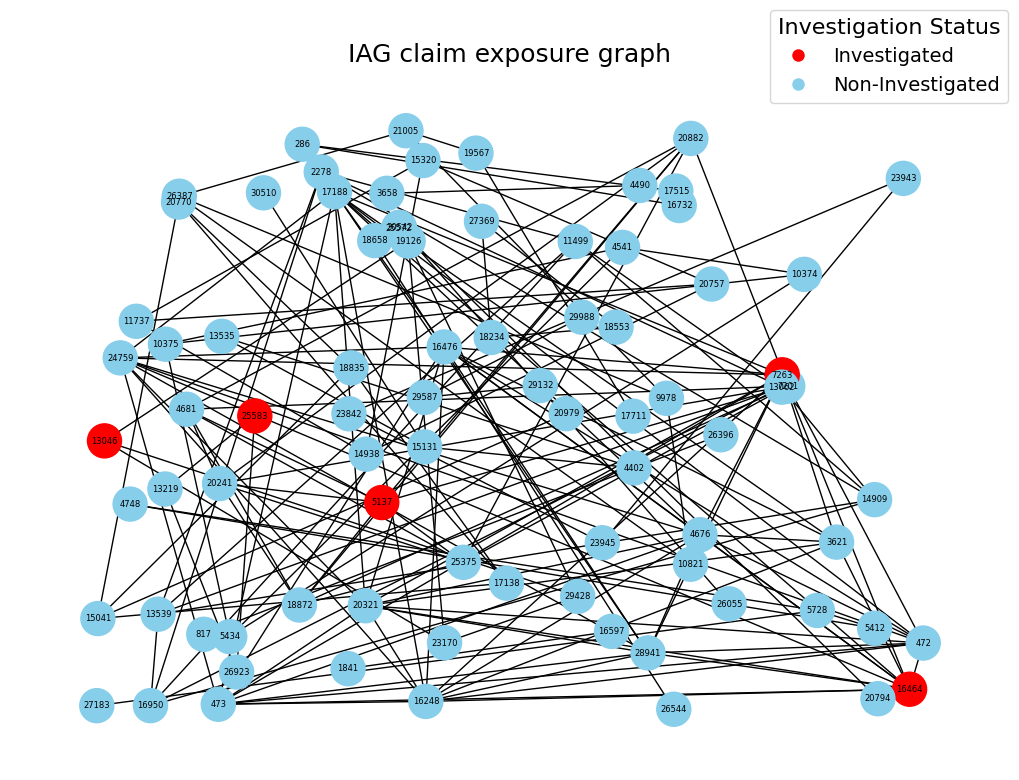

In [157]:
visualize_G(G_sub)

In [41]:
save_data(G, conf.data_path, 'ctp_network', data_extension='pkl')

Data saved successfully locally as pickle: C:\GitHub\CTP_syndicate_model\data\ctp_network.pkl


In [42]:
save_data(all_nodes_df, conf.data_path, 'node_data', data_extension='csv')

Data saved successfully locally as CSV: C:\GitHub\CTP_syndicate_model\data\node_data.csv


### 2.5 Graph Visualization

In [34]:
def visualize_community(G, communities, community_idx):
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Build the subgraph for this community ---
    selected = communities[community_idx]
    C = G.subgraph(selected)

    # --- Node colours based on 'y' ---
    node_colors = [
        'red' if data.get('y') == 1 else 'skyblue'
        for _, data in C.nodes(data=True)
    ]

    # --- Edge labels (
    # 
    #  + connection_type) ---
    edge_labels = {}
    for u, v, data in C.edges(data=True):
        parts = []
        if 'edge_weight' in data:
            parts.append(f"W: {data['edge_weight']}")
        ct = data.get('connection_type')
        if ct:
            if isinstance(ct, (list, tuple, set)):
                parts.append("Type: " + ", ".join(map(str, ct)))
            else:
                parts.append("Type: " + str(ct))
        edge_labels[(u, v)] = "\n".join(parts)

    # --- Gather unique connection types ---
    conn_types = set()
    for _, _, data in C.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)):
            conn_types.update(ct)
        elif ct is not None:
            conn_types.add(ct)

    # --- Map each type to a colour from tab10 ---
    cmap = plt.get_cmap('tab10')
    type_to_color = {
        ct: cmap(i % cmap.N)
        for i, ct in enumerate(sorted(conn_types))
    }
    default_edge_color = 'grey'

    # --- Build per-edge colour list ---
    edge_colors = []
    for _, _, data in C.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)) and ct:
            key = next(iter(ct))
            edge_colors.append(type_to_color.get(key, default_edge_color))
        elif ct is not None:
            edge_colors.append(type_to_color.get(ct, default_edge_color))
        else:
            edge_colors.append(default_edge_color)

    # --- Draw ---
    pos = nx.kamada_kawai_layout(C)
    plt.figure(figsize=(6, 4))
    nx.draw(
        C, pos,
        node_color=node_colors,
        edge_color=edge_colors,
        with_labels=False,
        node_size=400
    )
    nx.draw_networkx_labels(
        C, pos,
        labels={n: d.get('claim_exposure_id', str(n)) for n, d in C.nodes(data=True)},
        font_size=6
    )

    # --- Legend for types ---
    for ct, col in type_to_color.items():
        plt.plot([], [], color=col, label=str(ct))
    plt.legend(title="Connection Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(f"Subgraph for Community {community_idx}")
    plt.tight_layout()
    plt.show()


### 2.6 Community Detection

In [44]:
G=load_data(conf.data_path, 'ctp_network', data_extension='pkl')

Loading data locally: C:\GitHub\CTP_syndicate_model\data\ctp_network.pkl


In [35]:
from collections import defaultdict
from community import community_louvain
from typing import List, Set, Dict, Hashable

def recursive_community_detection(
    G: nx.Graph,
    communities_out: list,
    resolution: float,
    threshold: int,
    seed_value: int = 42,
    init_partition: dict =None
):
    """
    Recursively split G into communities using Louvain (best_partition), until each
    resulting subgraph has <= threshold nodes. Appends each final community's node set
    into `communities_out`.

    Parameters
    ----------
    G : nx.Graph
        (Preferably undirected; if directed, convert with `G.to_undirected()`)
        Must carry edge weights in 'edge_weight' if you want weighted Louvain.
    communities_out : list
        A list that will be appended with `set(node_ids)` for each final community.
    resolution : float
        Louvain resolution parameter (higher → more/smaller communities).
    threshold : int
        Max size of a leaf community; if |G| <= threshold, stop splitting.
    seed_value : int
        Random seed for determinism.
    init_partition : dict | None
        Optional warm start mapping node -> community_id. Can be partial; nodes
        not present will be initialized by the algorithm.
    """
    # Seed for reproducibility
    random.seed(seed_value)
    np.random.seed(seed_value)

    n = G.number_of_nodes()
    if n == 0:
        return
    if n <= threshold:
        communities_out.append(set(G.nodes))
        return

    # If graph is directed, Louvain expects undirected; convert on the fly.
    if G.is_directed():
        G = G.to_undirected()

    # Filter the initial partition to nodes in this subgraph (if provided)
    sub_init = None
    if init_partition:
        sub_init = {u: c for u, c in init_partition.items() if u in G}

    # Run Louvain with warm start
    part = community_louvain.best_partition(
        G,
        partition=sub_init,                # warm start (can be None)
        weight="edge_weight",             # your edge weight field
        resolution=resolution,
        random_state=seed_value
    )
    # Group nodes by community id
    label2nodes = defaultdict(set)
    for u, lbl in part.items():
        label2nodes[lbl].add(u)

    # If no split happened (all nodes in one community), stop here
    if len(label2nodes) <= 1:
        communities_out.append(set(G.nodes))
        return

    # Recurse into each community
    for nodes in label2nodes.values():
        subG = G.subgraph(nodes).copy()   # copy to avoid view surprises
        # Warm start for the child call:
        # You can pass `part` (filtered inside) or `None`. Passing it can speed up refinement.
        recursive_community_detection(
            subG,
            communities_out,
            resolution=resolution,
            threshold=threshold,
            seed_value=seed_value,
            init_partition=part
        )


In [36]:
def communities_to_partition(final_communities: List[Set[Hashable]]) -> Dict[Hashable, int]:
    """
    Convert a list of node-sets into a partition mapping: node -> community_id.
    Community IDs are 0..K-1 in the order they appear.
    """
    partition = {}
    for cid, nodes in enumerate(final_communities):
        for u in nodes:
            # If overlaps exist, the last assignment wins. Change to `raise` if you prefer strictness.
            partition[u] = cid
    return partition

In [37]:
final_communities=[]
recursive_community_detection( G,
    final_communities,
    resolution=1.2,      # try a different resolution if you want more/smaller splits
    threshold=50,        # your stopping size
    seed_value=42,
    init_partition=None)
print(f"Detected {len(final_communities)} communities.")

Detected 757 communities.


In [38]:
final_communities

[{25, 865, 2747, 21513, 24825},
 {167, 168, 169, 170, 1822},
 {171, 172},
 {191, 15223},
 {230, 3928, 25861},
 {273, 478},
 {282, 25806},
 {285, 286, 2448, 12522, 16732, 17515, 26118},
 {293, 3722, 3723},
 {310,
  1077,
  1637,
  2013,
  2705,
  2737,
  3246,
  3412,
  4498,
  4519,
  4681,
  5137,
  5265,
  5289,
  5421,
  6605,
  6613,
  7117,
  7123,
  7201,
  7202,
  7238,
  7239,
  7693,
  7925,
  8076,
  8090,
  8884,
  9977,
  9978,
  9979,
  10821,
  11009,
  11010,
  11107,
  11235,
  11394,
  12061,
  12144,
  12321,
  12495,
  12820,
  12897,
  13195,
  13704,
  13753,
  14022,
  14227,
  14228,
  14759,
  15016,
  15135,
  16925,
  17675,
  17676,
  17677,
  17711,
  18125,
  18242,
  18862,
  18872,
  19567,
  19898,
  20241,
  20343,
  20490,
  20882,
  20898,
  21005,
  21332,
  21333,
  21784,
  22344,
  22894,
  23257,
  23476,
  23495,
  23496,
  23792,
  23876,
  24295,
  24461,
  24490,
  24624,
  24882,
  25296,
  25375,
  25654,
  25731,
  25737,
  26387,
  27109,

In [ ]:
save_data(final_communities, conf.data_path, 'communities', data_extension='pkl')

Data saved successfully locally as pickle: C:\GitHub\CTP_syndicate_model\data\communities.pkl


In [ ]:
# def recursive_community_detection(G, communities_list,resolution,threshold,seed_value=42):

#     random.seed(seed_value)
#     np.random.seed(seed_value)
#     # If the graph has 50 or fewer nodes, append it to the final communities list
#     if G.number_of_nodes() <= threshold:
#         communities_list.append(set(G.nodes))
#     else:
#         # Perform community detection on the subgraph
#         # communities = nx.community.greedy_modularity_communities(G, weight='edge_weight', resolution=resolution)
#         communities = louvain_communities(G, weight='edge_weight', resolution=resolution, seed=seed_value)
        
#         # Apply the function recursively on the detected communities
#         for community in communities:
#             subgraph = G.subgraph(community)
#             recursive_community_detection(subgraph, communities_list,resolution=resolution,threshold=threshold)

### 2.7 Community Analysis

In [63]:
# Function to compute conductance
def compute_conductance(graph, community):
    vol_community = sum(dict(graph.degree(community)).values())
    edge_boundary = len(list(nx.edge_boundary(graph, community)))
    vol_rest = sum(dict(graph.degree(graph.nodes - community)).values())

    if vol_community>0 and vol_rest>0:  
        return edge_boundary / min(vol_community, vol_rest)  
    else:
        return 0

In [64]:
def cal_metrics_community(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)

        edge_weights = [data.get('edge_weight', 0) for u, v, data in subgraph.edges(data=True)]
        total_weight = sum(edge_weights)
        avg_edge_weight = total_weight / len(edge_weights) if edge_weights else 0

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_exposure_id']for node, data in subgraph.nodes(data=True)]

        # Clustering coefficient (average for nodes in the community)
        avg_clustering = nx.average_clustering(subgraph)
        
        # Conductance
        conductance = compute_conductance(G, community)
        
        # Density
        density = nx.density(subgraph)
        
        # Triangle count (sum of triangles in the community)
        triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        
        # Add metrics to the list
        community_metrics.append({
            'Community': i,
            'Nodes': node_list,
            'Exposure list': claim_list,
            'Average edge weight':avg_edge_weight,
            'Clustering Coefficient': avg_clustering,
            'Conductance': conductance,
            'Density': density,
            'Triangle Count': triangles,
            'Size': len(community),
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [65]:
df_metrics = cal_metrics_community(G, final_communities)
df_metrics

,Community,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size
0,0,"[865, 21513, 24825, 2747, 25]","[NWRTP1800662_1, NWRTP2301770_1, NWRTP2401164_...",0.075,0.700,0.000,0.700,4,5
1,1,"[167, 168, 169, 170, 1822]","[NWRTP1800127_2, NWRTP1800127_3, NWRTP1800127_...",0.003,1.000,0.000,1.000,10,5
2,2,"[171, 172]","[NWRTP1800128_1, NWRTP1800128_2]",1.250,0.000,0.000,1.000,0,2
3,3,"[191, 15223]","[NWRTP1800140_1, NWRTP2102448_1]",0.251,0.000,0.000,1.000,0,2
4,4,"[3928, 25861, 230]","[NWRTP1802954_2, NWRTP2402017_1, NWRTP1800172_1]",0.250,1.000,0.000,1.000,1,3
...,...,...,...,...,...,...,...,...,...
752,752,"[30857, 30603, 30829, 30800, 30801, 30267]","[NWRTP2502315_1, NWRND2500186_1, NWRTP2502292_...",0.002,1.000,0.000,1.000,20,6
753,753,"[31073, 30323]","[NWRTP2501891_2, NWRTP2501891_1]",0.250,0.000,0.000,1.000,0,2
754,754,"[30448, 30425, 30445, 30447]","[NWRTP2303012_7, NWRTP2303012_2, NWRTP2303012_...",0.007,1.000,0.000,1.000,4,4
755,755,"[30645, 30639]","[NWRTP2502136_2, NWRTP2502136_1]",0.250,0.000,0.000,1.000,0,2


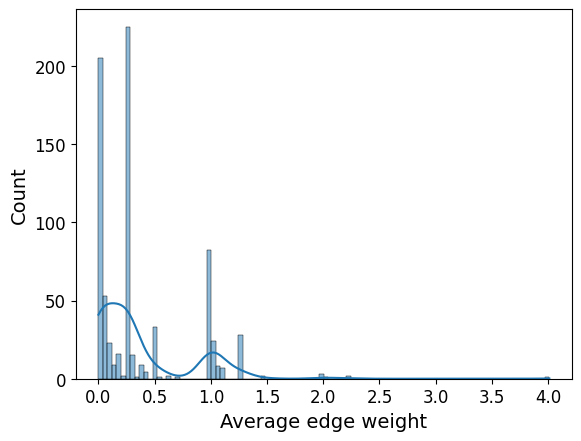

In [83]:
sns.histplot(df_metrics['Average edge weight'], kde=True, bins=100) 
plt.show()

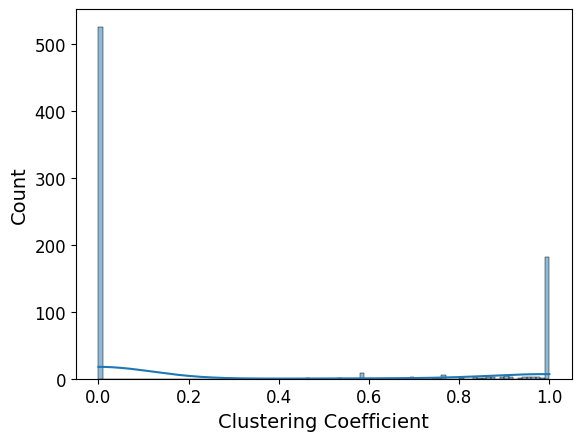

In [84]:
sns.histplot(df_metrics['Clustering Coefficient'], kde=True, bins=100) 
plt.show()

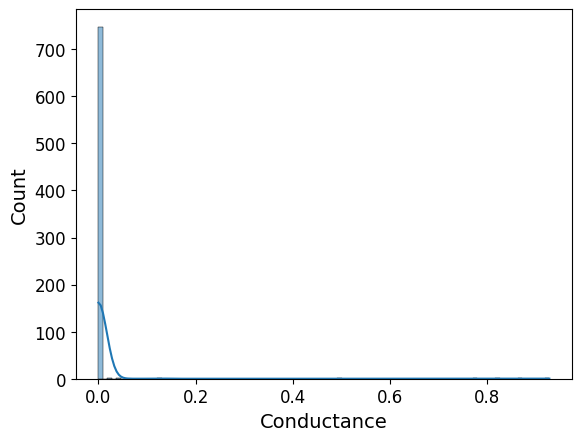

In [85]:
sns.histplot(df_metrics['Conductance'], kde=True, bins=100) 
plt.show()

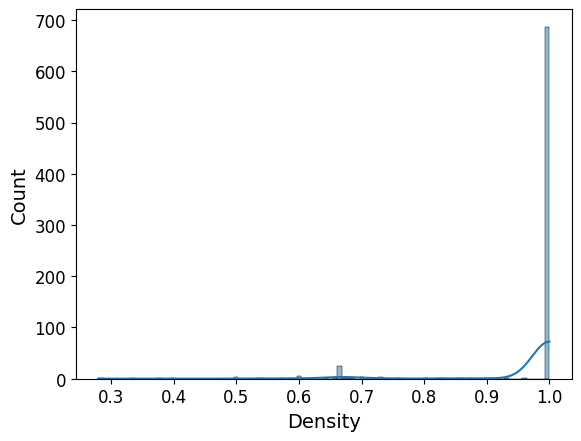

In [86]:
sns.histplot(df_metrics['Density'], kde=True, bins=100) 
plt.show()

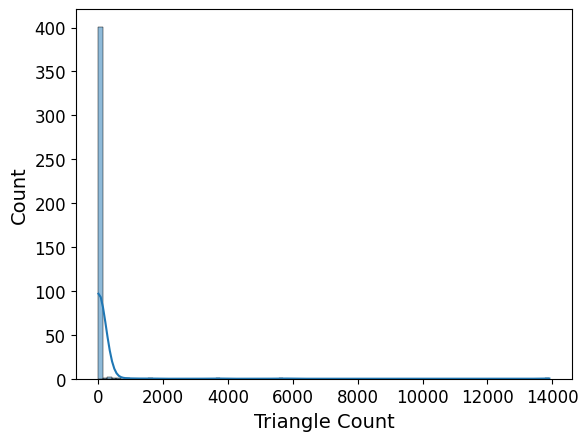

In [64]:
sns.histplot(df_metrics['Triangle Count'], kde=True, bins=100) 
plt.show()

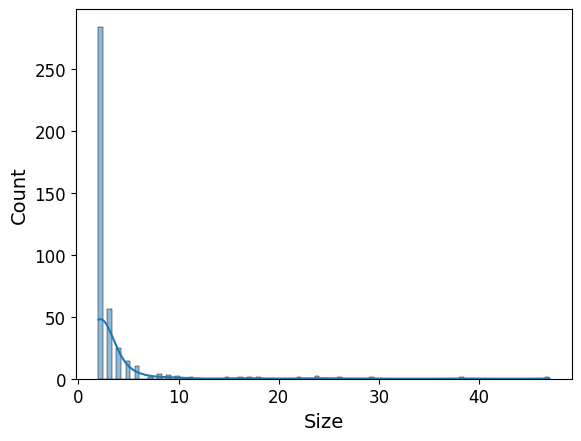

In [65]:
sns.histplot(df_metrics['Size'], kde=True, bins=100) 
plt.show()

In [94]:
# Filter communities based on criteria 
filtered_metrics = df_metrics[
    (df_metrics['Clustering Coefficient'] > 0.9) &  
    (df_metrics['Conductance'] < 0.1) &             
    (df_metrics['Density'] > 0.9) &                 
    # (df_metrics['Triangle Count'] > 2) &
    # (df_metrics['Average edge weight'] > 0.01) &
    (df_metrics['Size'] >=4 )         
].reset_index(drop=True)  

In [95]:
filtered_metrics

,Community,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size
0,1,"[167, 168, 169, 170, 1822]","[NWRTP1800127_2, NWRTP1800127_3, NWRTP1800127_...",0.003,1.000,0.000,1.000,10,5
1,12,"[28421, 14342, 28422, 16136, 16137, 18440, 308...","[NWRTP2500441_1, NWRTP2101754_1, NWRTP2500441_...",0.000,0.951,0.002,0.915,35427,65
2,14,"[561, 3604, 3605, 7974]","[NWRND1800026_1, NWRTP1802783_1, NWRTP1802783_...",0.069,1.000,0.000,1.000,4,4
3,17,"[11184, 11185, 630, 5526]","[NWRTP2002131_1, NWRTP2002131_2, NWRTP1800481_...",0.007,1.000,0.000,1.000,4,4
4,20,"[5728, 5412, 1286, 2152, 4748, 27183, 690, 6907]","[NWRTP1901353_1, NWRTP1901099_1, NWRTP1800992_...",0.029,0.940,0.000,0.929,45,8
...,...,...,...,...,...,...,...,...,...
73,738,"[29362, 29363, 29364, 29365]","[NWRTP2501158_1, NWRTP2501158_2, NWRTP2501158_...",0.011,1.000,0.000,1.000,4,4
74,739,"[29409, 29410, 29411, 29412]","[NWRTP2500571_2, NWRTP2500571_3, NWRTP2500571_...",0.012,1.000,0.000,1.000,4,4
75,752,"[30857, 30603, 30829, 30800, 30801, 30267]","[NWRTP2502315_1, NWRND2500186_1, NWRTP2502292_...",0.002,1.000,0.000,1.000,20,6
76,754,"[30448, 30425, 30445, 30447]","[NWRTP2303012_7, NWRTP2303012_2, NWRTP2303012_...",0.007,1.000,0.000,1.000,4,4


In [68]:
ranked_metrics = filtered_metrics.sort_values(by=['Average edge weight','Conductance','Clustering Coefficient','Density','Size'], ascending=[False, True,False,False,False]).reset_index(drop=True)
filtered_communities = ranked_metrics['Nodes'].tolist()
len(filtered_communities)

86

In [69]:
df_filtered_metrics = cal_metrics_community(G, filtered_communities)
df_filtered_metrics.head(5)

,Community,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size
0,0,"[21691, 13268, 13334, 13380]","[NWRTP2301902_1, NWRTP2100896_1, NWRTP2100896_...",0.117,1.000,0.000,1.000,4,4
1,1,"[20640, 29048, 21536, 900]","[NWRTP2301059_1, NWRTP2500893_2, NWRTP2301789_...",0.111,1.000,0.000,1.000,4,4
2,2,"[9663, 24730, 19102, 8719]","[NWRTP2000927_1, NWRTP2401085_1, NWRTP2202655_...",0.102,0.833,0.000,0.833,2,4
3,3,"[28200, 19781, 8004, 8005]","[NWRTP2500273_1, NWRTP2300145_5, NWRTP1903180_...",0.100,1.000,0.000,1.000,4,4
4,4,"[1160, 10248, 25348, 26525]","[NWRTP1800898_1, NWRTP2001387_1, NWRTP2401598_...",0.097,1.000,0.000,1.000,4,4


In [70]:
df_filtered_metrics['rank by weight'] = df_filtered_metrics['Average edge weight'].rank(method='dense', ascending=False).astype(int)
df_filtered_metrics = df_filtered_metrics.rename(columns={'Community': 'Community_id'}).reset_index(drop=True)
df_filtered_metrics.head(10)

,Community_id,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size,rank by weight
0,0,"[21691, 13268, 13334, 13380]","[NWRTP2301902_1, NWRTP2100896_1, NWRTP2100896_...",0.117,1.000,0.000,1.000,4,4,1
1,1,"[20640, 29048, 21536, 900]","[NWRTP2301059_1, NWRTP2500893_2, NWRTP2301789_...",0.111,1.000,0.000,1.000,4,4,2
2,2,"[9663, 24730, 19102, 8719]","[NWRTP2000927_1, NWRTP2401085_1, NWRTP2202655_...",0.102,0.833,0.000,0.833,2,4,3
3,3,"[28200, 19781, 8004, 8005]","[NWRTP2500273_1, NWRTP2300145_5, NWRTP1903180_...",0.100,1.000,0.000,1.000,4,4,4
4,4,"[1160, 10248, 25348, 26525]","[NWRTP1800898_1, NWRTP2001387_1, NWRTP2401598_...",0.097,1.000,0.000,1.000,4,4,5
5,5,"[10520, 16117, 6298, 5437]","[NWRTP1903543_2, NWRTP2101045_2, NWRTP1901828_...",0.083,1.000,0.000,1.000,4,4,6
6,6,"[26272, 15506, 18419, 21903]","[NWRTP2402348_1, NWRTP2102678_1, NWRTP2202124_...",0.082,0.833,0.000,0.833,2,4,7
7,7,"[25208, 21779, 25604, 23967]","[NWRTP2401432_5, NWRTP2301973_1, NWRTP2401809_...",0.075,1.000,0.000,1.000,4,4,8
8,8,"[10090, 10535, 3709, 10503]","[NWRTP1902578_10, NWRTP1902578_11, NWRTP180286...",0.074,1.000,0.000,1.000,4,4,9
9,9,"[561, 3604, 3605, 7974]","[NWRND1800026_1, NWRTP1802783_1, NWRTP1802783_...",0.069,1.000,0.000,1.000,4,4,10


In [71]:
def generate_output(G, communities):
    """
    Given a NetworkX graph G and a list of communities (each a list of node IDs),
    returns a DataFrame with one row per undirected edge–relationship pair:
      Community_id | Claim 1 | Claim 2 | Relationship Type | Relationship Party

    Assumes:
      - G.nodes[u]['claim_number'] exists for every node u
      - G.edges[u, v]['connection_type'] is a set of types
      - G.edges[u, v] may contain:
          cust_contact_name (str or set of str),
          doctor_contact_name (str or set of str),
          lawyer_contact_name,
          psych_contact_name,
          repair_contact_name,
          rego_number (str or set of str)
    """

    rows = []
    for community_id, community in enumerate(communities):
        sub = G.subgraph(community)
        seen = set()
        
        for u, v, edge_data in sub.edges(data=True):
            conn_types = edge_data.get('connection_type', list())
            for i, rel in enumerate(conn_types):
                key = tuple(sorted((u, v))) + (rel,)
                if key in seen:
                    continue
                seen.add(key)
                party= edge_data.get('party_name', list())[i]
                contact= edge_data.get('party_contact_number', list())[i]
                # prepare party based on relationship type
                               
                rows.append({
                    'Community_id':       community_id,
                    'Claim exposure 1':            G.nodes[u]['claim_exposure_id'],
                    'Claim exposure 2':            G.nodes[v]['claim_exposure_id'],
                    'Relationship Type':  rel,
                    'Relationship Party': party,
                    'Party Contact': contact
                })
    
    return pd.DataFrame(rows)

In [72]:
output_df=generate_output(G, filtered_communities)
output_df

,Community_id,Claim exposure 1,Claim exposure 2,Relationship Type,Relationship Party,Party Contact
0,0,NWRTP2301902_1,NWRTP2100896_1,doc_lawyer,"(doctor: Adib Obeid, lawyer: Turner Freeman La...","(doctor: 0296316033, lawyer: 0288332500)"
1,0,NWRTP2301902_1,NWRTP2100896_3,doc_lawyer,"(doctor: Amy Doldissen, lawyer: Turner Freeman...","(doctor: 0296316033, lawyer: 0288332500)"
2,0,NWRTP2301902_1,NWRTP2100896_4,doc_lawyer,"(doctor: Adib Obeid, lawyer: Turner Freeman La...","(doctor: 0296316033, lawyer: 0288332500)"
3,0,NWRTP2100896_1,NWRTP2100896_3,doc_lawyer,"(doctor: Edge Medical Centre, lawyer: Turner F...","(doctor: 0296316033, lawyer: 0288332500)"
4,0,NWRTP2100896_1,NWRTP2100896_4,doc_lawyer,"(doctor: Edge Medical Centre, lawyer: Turner F...","(doctor: 0296316033, lawyer: 0288332500)"
...,...,...,...,...,...,...
3170,85,NWRTP2101016_1,NWRTP2101016_2,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La...","(doctor: 0282111100, lawyer: None)"
3171,85,NWRTP2101016_1,NWRTP2101065_1,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La...","(doctor: 0482111100, lawyer: 0468331681)"
3172,85,NWRTP2101065_1,NWRTP1903246_1,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La...","(doctor: 0482111100, lawyer: 0468331681)"
3173,85,NWRTP2101065_1,NWRTP2101016_2,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La...","(doctor: 0482111100, lawyer: 0468331681)"


In [73]:
# rename df_encoded for Claim 1
df1 = all_nodes_df.rename(columns={
    'claim_exposure_id':           'Claim exposure 1',
    'claim_exposure_lodgement_date':   'Exposure 1 lodgement date',
    'claim_exposure_status_name':      'Exposure 1 status',
    'contact_full_name': 'Exposure 1 contact name',
    'fixed_contact_number': 'Exposure 1 contact number',
    'investigation_flag': 'Exposure 1 investigation flag',

})

# then rename df_encoded for Claim 2
df2 = all_nodes_df.rename(columns={
    'claim_exposure_id':           'Claim exposure 2',
    'claim_exposure_lodgement_date':   'Exposure 2 lodgement date',
    'claim_exposure_status_name':      'Exposure 2 status',
    'contact_full_name': 'Exposure 2 contact name',
    'fixed_contact_number': 'Exposure 2 contact number',
    'investigation_flag': 'Exposure 2 investigation flag'
})

# now merge onto output_df
df_output_merged = (
    output_df
    .merge(df1[['Claim exposure 1','Exposure 1 lodgement date','Exposure 1 status','Exposure 1 contact name', 'Exposure 1 contact number', 'Exposure 1 investigation flag']],
           on='Claim exposure 1', how='left')
    .merge(df2[['Claim exposure 2','Exposure 2 lodgement date','Exposure 2 status','Exposure 2 contact name', 'Exposure 2 contact number', 'Exposure 2 investigation flag']],
           on='Claim exposure 2', how='left')
)

new_order = [
    'Community_id',
    'Claim exposure 1', 'Exposure 1 lodgement date', 'Exposure 1 status','Exposure 1 contact name','Exposure 1 contact number','Exposure 1 investigation flag',
    'Claim exposure 2', 'Exposure 2 lodgement date', 'Exposure 2 status','Exposure 2 contact name','Exposure 2 contact number','Exposure 2 investigation flag',
    'Relationship Type', 'Relationship Party', 'Party Contact'
]

df_output_merged = df_output_merged[new_order]
df_output_merged['created date'] = date.today()
# inspect
df_output_merged.head()


,Community_id,Claim exposure 1,Exposure 1 lodgement date,Exposure 1 status,Exposure 1 contact name,Exposure 1 contact number,Exposure 1 investigation flag,Claim exposure 2,Exposure 2 lodgement date,Exposure 2 status,Exposure 2 contact name,Exposure 2 contact number,Exposure 2 investigation flag,Relationship Type,Relationship Party,Party Contact,created date
0,0,NWRTP2301902_1,2023-08-10,Open,Melina Gol,0455338389,0,NWRTP2100896_1,2021-04-14,Closed,Chantelle McLean,0407068242,0,doc_lawyer,"(doctor: Adib Obeid, lawyer: Turner Freeman La...","(doctor: 0296316033, lawyer: 0288332500)",2025-09-26
1,0,NWRTP2301902_1,2023-08-10,Open,Melina Gol,0455338389,0,NWRTP2100896_3,2021-04-20,Closed,Joseph Cassar,0407068242,0,doc_lawyer,"(doctor: Amy Doldissen, lawyer: Turner Freeman...","(doctor: 0296316033, lawyer: 0288332500)",2025-09-26
2,0,NWRTP2301902_1,2023-08-10,Open,Melina Gol,0455338389,0,NWRTP2100896_4,2021-04-23,Closed,Aliyah Cassar,0407068242,0,doc_lawyer,"(doctor: Adib Obeid, lawyer: Turner Freeman La...","(doctor: 0296316033, lawyer: 0288332500)",2025-09-26
3,0,NWRTP2100896_1,2021-04-14,Closed,Chantelle McLean,0407068242,0,NWRTP2100896_3,2021-04-20,Closed,Joseph Cassar,0407068242,0,doc_lawyer,"(doctor: Edge Medical Centre, lawyer: Turner F...","(doctor: 0296316033, lawyer: 0288332500)",2025-09-26
4,0,NWRTP2100896_1,2021-04-14,Closed,Chantelle McLean,0407068242,0,NWRTP2100896_4,2021-04-23,Closed,Aliyah Cassar,0407068242,0,doc_lawyer,"(doctor: Edge Medical Centre, lawyer: Turner F...","(doctor: 0296316033, lawyer: 0288332500)",2025-09-26


In [74]:
# df_final_output = df_output_merged.merge(df_filtered_metrics[['Community_id', 'rank by weight']], on='Community_id', how='left')
# df_final_output.head(10)

In [75]:
# output_df.index.name = 'community_id'

# # Perform the join by resetting the index so we can join on it like a regular column
# merged_df = output_df.reset_index().merge(
#     ranked_metrics,
#     how='inner',
#     left_on='community_index',
#     right_on='Community'
# )
# merged_df.head(10)

In [76]:
# merged_df.drop(columns=['Community','Nodes', 'Claim Numbers'], inplace=True)

C:\Users\s745998\AppData\Local\Temp\ipykernel_22636\3601805149.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


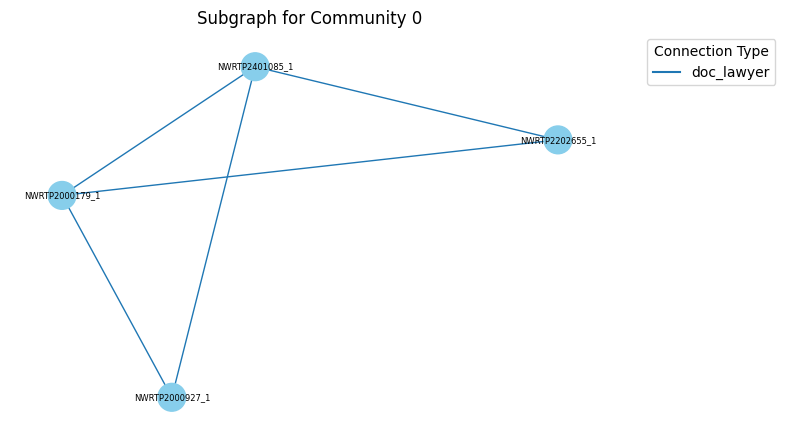

In [60]:
visualize_community(G, filtered_communities, 0)

C:\Users\s745998\AppData\Local\Temp\ipykernel_23196\3601805149.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


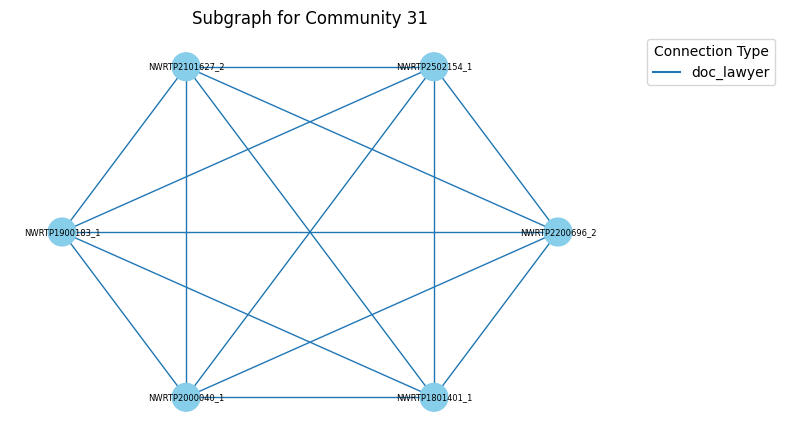

In [57]:
visualize_community(G, filtered_communities, 31)

# 3 Implement algorithms on Claim Network

In [74]:
import pytz
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, \
    f1_score, confusion_matrix, auc, precision_recall_curve,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
# from pygod.detector import DOMINANT
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from network import Dominant
import optuna

c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [75]:
print("num_nodes:", data.x.size(0))
print("max edge index:", int(data.edge_index.max()))

num_nodes: 31298
max edge index: 31275


In [81]:
# import torch
# import torch_geometric

# print("Torch version:", torch.__version__)
# print("Torch Geometric version:", torch_geometric.__version__)

### 3.1 Hyperparameter tuning on DOMINANT model

In [76]:
class networkEvaluator:
    """
    conf: from Conf class
    model_IF: isolation forest model
    x: input dataframe
    y: target value
    id_df: index columns of dataframe
    csv_filename: name of saving file
    thresh: threshold for model IF decision fucntion
    metric1: use as objective in HP, key in metrics dictionary
    metric2: use for comparison in plot, key in metrics dictionary
    """

    def __init__(self, conf):
        self.conf = conf

    @staticmethod
    def evaluate (conf, model, data, id_df, thresh, MODEL_TAG, csv_filename, metric1, metric2):
        anomaly_scores, y_emb=model.predict(data, get_emb=True)
        y_score = anomaly_scores.numpy()
        y_score = pd.Series(y_score, name='y_score')
        y_real= pd.Series(id_df['investigation_flag'], name='y')
        combined_df = pd.concat([y_score.reset_index(drop=True), 
                                 y_real.reset_index(drop=True)], axis=1)
        combined_df['y_pred'] = np.where(combined_df['y_score'] >= thresh, 1, 0)
        alert_vol =  sum(combined_df['y_pred'] == 1)
        
        precision = precision_score(combined_df['y'], combined_df['y_pred'])
        recall = recall_score(combined_df['y'], combined_df['y_pred'])
        f1 = f1_score(combined_df['y'], combined_df['y_pred'])
        conf_matrix = confusion_matrix(combined_df['y'], combined_df['y_pred'])
        precision2, recall2, _ = precision_recall_curve(combined_df['y'], combined_df['y_score'])
        pr_auc = auc(recall2, precision2)
        auc_roc_score = roc_auc_score(combined_df['y'], combined_df['y_score'])

        metrics = {
            "alert_vol": alert_vol,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Confusion Matrix": conf_matrix,
            "AUC-PR": pr_auc,
            "AUC-ROC": auc_roc_score
        }
        # Print metrics
        print("Evaluation Metrics:")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value}")
        
        # Save meitrics to CSV
        networkEvaluator.save_metrics_to_csv(MODEL_TAG, metrics,
                                                     metric1, metric2, csv_filename)
        return metrics, combined_df

    @staticmethod
    def save_metrics_to_csv(MODEL_TAG, metrics, metric1, metric2, csv_filename):
        try:
            metric_df = pd.read_csv(csv_filename)
        except FileNotFoundError:
            metric_df = pd.DataFrame(columns=['Model', metric1, metric2])

        new_row = pd.DataFrame({'Model': [MODEL_TAG], 
                                metric1: [metrics[metric1]], 
                                metric2: [metrics[metric2]]})
        
        metric_df = pd.concat([metric_df, new_row], ignore_index=True)
        metric_df.to_csv(csv_filename, index=False)


# evaluator for Random forest 

In [77]:

class networkTrainer:
    """
    use metric1 as objective
    use metirc2 as comparison in plot

    """
    def __init__(self, conf, data, id_train, metric1, metric2):
        self.conf = conf
        self.data = data
        self.id_train = id_train
        self.metric1 = metric1
        self.metric2 = metric2
        self.metric_results = []

    def objective(self, trial):
        # Suggest values for the hyperparameters
        hidden_size = trial.suggest_int('hidden_size', 5, self.data.x.shape[1], step=1 )
        num_epochs = trial.suggest_int('num_epochs', 50, 100, step=5 )
        learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1) 
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
        dropout = trial.suggest_uniform('dropout', 0, 0.5) 
        # Create the model with suggested hyperparameters
        params={
            'hidden_size': hidden_size,
            'num_epochs': num_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'dropout': 0
        }
        # threshold = trial.suggest_uniform('threshold', 0, 0.5)  # Optimize threshold
        MODEL_TAG = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
        model = self.train_model(self.data, params)
        metrics, combined_df = networkEvaluator.evaluate(self.conf, model, self.data, self.id_train, 
                        500, MODEL_TAG, self.conf.artefact_path + "/metrics_train.csv", 
                        self.metric1, self.metric2)
        # Save the metrics for later plotting
        self.metric_results.append({self.metric1:metrics[self.metric1], self.metric2:metrics[self.metric2]})
        return metrics[self.metric1]
    

    def train_model(self, data, params):
        model = Dominant(feat_size=data.x.shape[1], hidden_size=params['hidden_size'], dropout=params['dropout'])
        model.train_model(data, num_epochs=params['num_epochs'], learning_rate=params['learning_rate'], weight_decay=params['weight_decay'])
        return model

    def train_with_optuna(self, n_trials=50):
        study = optuna.create_study(direction='maximize')
        study.optimize(self.objective, n_trials)  # 100 trials

        best_params = study.best_params

        # Plot A2I and "New R2I" curves after all trials are finished
        self.plot_metrics_curve()

        return best_params, study

    def plot_metrics_curve(self):
        # Retrieve the desired metrics from the results
        metric1_values = [result[self.metric1] for result in self.metric_results]
        metric2_values = [result[self.metric2] for result in self.metric_results]
        trials = np.arange(1, len(metric1_values) + 1)

        # Plot the selected metrics
        plt.figure(figsize=(10, 6))
        plt.plot(trials, metric1_values, marker='o', linestyle='-', color='b', label=self.metric1)
        plt.plot(trials, metric2_values, marker='o', linestyle='-', color='r', label=self.metric2)
        plt.title('Performance Metrics for Hyperparameter Tuning Trials')
        plt.xlabel('Trial')
        plt.ylabel('Score')
        plt.legend()
        plt.tight_layout()
        plt.show()

[I 2025-09-26 18:10:02,336] A new study created in memory with name: no-name-4c764803-6882-4f03-8c22-38cd1eca130b


************************************************************
HP tuning started...


C:\Users\s745998\AppData\Local\Temp\ipykernel_29812\3395842246.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_29812\3395842246.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_29812\3395842246.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0, 0.5)


Epoch 1/65, Loss: 158580320.00, Struct loss: 67051216.00, Attr loss: 91529.09
Epoch 2/65, Loss: 93076088.00, Struct loss: 2104147.25, Attr loss: 90971.95
Epoch 3/65, Loss: 88693744.00, Struct loss: 2842017.00, Attr loss: 85851.73
Epoch 4/65, Loss: 79929864.00, Struct loss: 3666.60, Attr loss: 79926.20
Epoch 5/65, Loss: 72405552.00, Struct loss: 111.29, Attr loss: 72405.44
Epoch 6/65, Loss: 65274508.00, Struct loss: 0.50, Attr loss: 65274.51
Epoch 7/65, Loss: 58090244.00, Struct loss: 0.00, Attr loss: 58090.24
Epoch 8/65, Loss: 49457988.00, Struct loss: 0.00, Attr loss: 49457.99
Epoch 9/65, Loss: 39078752.00, Struct loss: 0.00, Attr loss: 39078.75
Epoch 10/65, Loss: 27595220.00, Struct loss: 0.00, Attr loss: 27595.22
Epoch 11/65, Loss: 17359830.00, Struct loss: 0.00, Attr loss: 17359.83
Epoch 12/65, Loss: 12481620.00, Struct loss: 0.10, Attr loss: 12481.62
Epoch 13/65, Loss: 13674217.00, Struct loss: 0.00, Attr loss: 13674.22
Epoch 14/65, Loss: 16985690.00, Struct loss: 0.00, Attr loss:

[I 2025-09-26 18:18:03,382] Trial 0 finished with value: 0.01702127659574468 and parameters: {'hidden_size': 7, 'num_epochs': 65, 'learning_rate': 0.03993417106846549, 'weight_decay': 0.026340111911529237, 'dropout': 0.040934769302101215}. Best is trial 0 with value: 0.01702127659574468.


...

Evaluation Metrics:
alert_vol: 23
Precision: 0.043478260869565216
Recall: 0.0049261083743842365
F1 Score: 0.008849557522123894
Confusion Matrix: [[31073    22]
 [  202     1]]
AUC-PR: 0.02370374393186602
AUC-ROC: 0.7814786563027494


C:\Users\s745998\AppData\Local\Temp\ipykernel_29812\3395842246.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_29812\3395842246.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_29812\3395842246.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0, 0.5)


Epoch 1/100, Loss: 12124054528.00, Struct loss: 12032742400.00, Attr loss: 91312.45
Epoch 2/100, Loss: 146488688.00, Struct loss: 68704688.00, Attr loss: 77784.00
Epoch 3/100, Loss: 70602696.00, Struct loss: 2871972.25, Attr loss: 67730.72
Epoch 4/100, Loss: 52151508.00, Struct loss: 142695.45, Attr loss: 52008.81
Epoch 5/100, Loss: 43656608.00, Struct loss: 10496.02, Attr loss: 43646.11
Epoch 6/100, Loss: 39408572.00, Struct loss: 0.00, Attr loss: 39408.57
Epoch 7/100, Loss: 42245888.00, Struct loss: 0.00, Attr loss: 42245.89
Epoch 8/100, Loss: 37117228.00, Struct loss: 0.00, Attr loss: 37117.23
Epoch 9/100, Loss: 28494958.00, Struct loss: 0.00, Attr loss: 28494.96
Epoch 10/100, Loss: 24356004.00, Struct loss: 0.00, Attr loss: 24356.00
Epoch 11/100, Loss: 23714916.00, Struct loss: 0.00, Attr loss: 23714.92
Epoch 12/100, Loss: 22091536.00, Struct loss: 0.00, Attr loss: 22091.54
Epoch 13/100, Loss: 17734810.00, Struct loss: 0.00, Attr loss: 17734.81
Epoch 14/100, Loss: 14751767.00, Stru

[I 2025-09-26 21:35:59,365] Trial 19 finished with value: 0.017167381974248927 and parameters: {'hidden_size': 11, 'num_epochs': 100, 'learning_rate': 0.07658450081856605, 'weight_decay': 0.01888837472817696, 'dropout': 0.3888676346041523}. Best is trial 2 with value: 0.05295315682281059.


Evaluation Metrics:
alert_vol: 30
Precision: 0.06666666666666667
Recall: 0.009852216748768473
F1 Score: 0.017167381974248927
Confusion Matrix: [[31067    28]
 [  201     2]]
AUC-PR: 0.021364509310056366
AUC-ROC: 0.7750887356955525


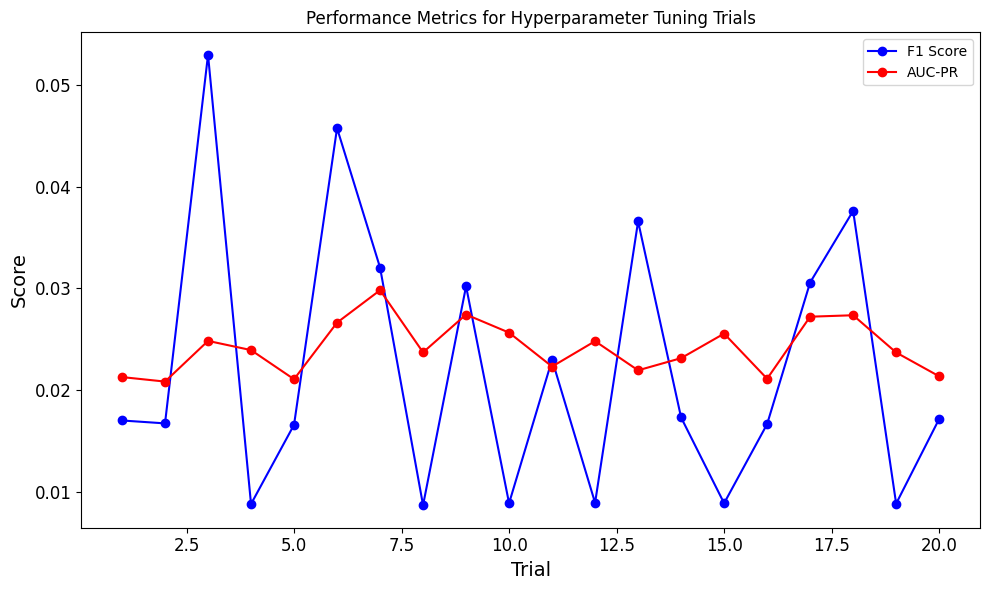

Best Parameters: {'hidden_size': 8, 'num_epochs': 70, 'learning_rate': 0.09430326491204476, 'weight_decay': 0.0008543800925373958, 'dropout': 0.3415002706283968}
HP tuning finished...
************************************************************

Elapsed time (model HP tuning): 3:25:57.346
Total elapsed time: 4:26:11.885


In [78]:
# init params
hptrial = 20 # number of trials in HP tuning
metric1 = 'F1 Score' # use as objective in HP tuning
metric2 = 'AUC-PR' # use for HP tuning tracking

# train_tag = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
print('*' * 60)
print('HP tuning started...')
# use New T2D as objective
# run on 2024-02-16
function_start_time = time.time()
# Instantiate the trainer
trainer = networkTrainer(conf, data, all_nodes_df, metric1, metric2)
# Train with Optuna
best_params, study = trainer.train_with_optuna(n_trials=hptrial)
trial_data = study.trials_dataframe()
# save_pkl(best_params, conf.artefact_path, "best_params", data_extension="pkl")
# save_pkl(trial_data, conf.artefact_path, "trial_data_{}".format(train_tag), data_extension="pkl")
print("Best Parameters:", best_params)
print('HP tuning finished...')
print('*' * 60)
elapsed_time('model HP tuning', project_start_time, function_start_time)

In [81]:
save_data(best_params, conf.artefact_path, "best_params", data_extension="pkl")

Data saved successfully locally as pickle: C:\GitHub\CTP_syndicate_model\models\best_params.pkl


### 3.2 Train model and extract network embeddings

In [82]:
# Initialize model
model = Dominant(feat_size=data.x.shape[1], hidden_size=best_params['hidden_size'], dropout=0)
model.train_model(data, num_epochs=best_params['num_epochs'], learning_rate=best_params['learning_rate'], weight_decay=best_params['weight_decay'])
# save model
train_tag = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
torch.save(model, os.path.join(conf.models_path, "dominant_AD_model_{}.pth".format(train_tag)))

Epoch 1/70, Loss: 10569298944.00, Struct loss: 10477705216.00, Attr loss: 91593.77
Epoch 2/70, Loss: 101855280.00, Struct loss: 17873124.00, Attr loss: 83982.16
Epoch 3/70, Loss: 92091672.00, Struct loss: 7211291.50, Attr loss: 84880.38
Epoch 4/70, Loss: 86674096.00, Struct loss: 2993211.00, Attr loss: 83680.89
Epoch 5/70, Loss: 82732512.00, Struct loss: 568139.31, Attr loss: 82164.38
Epoch 6/70, Loss: 79869184.00, Struct loss: 1403.73, Attr loss: 79867.78
Epoch 7/70, Loss: 72584080.00, Struct loss: 19351.80, Attr loss: 72564.73
Epoch 8/70, Loss: 61554096.00, Struct loss: 815012.31, Attr loss: 60739.09
Epoch 9/70, Loss: 56495624.00, Struct loss: 988170.88, Attr loss: 55507.45
Epoch 10/70, Loss: 53377160.00, Struct loss: 1326.12, Attr loss: 53375.83
Epoch 11/70, Loss: 39522468.00, Struct loss: 0.00, Attr loss: 39522.47
Epoch 12/70, Loss: 30335904.00, Struct loss: 0.00, Attr loss: 30335.90
Epoch 13/70, Loss: 25598716.00, Struct loss: 0.00, Attr loss: 25598.72
Epoch 14/70, Loss: 20194544.

### 3.3 Evaluate graph anomaly detection model

In [28]:
load_tag='2025-09-04-20-40'
model = torch.load(os.path.join(conf.models_path, "dominant_AD_model_{}.pth".format(load_tag)))
anomaly_scores, y_emb=model.predict(data, get_emb=True)

C:\Users\s745998\AppData\Local\Temp\ipykernel_29036\2858466209.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(os.path.join(conf.models_path, "dominan

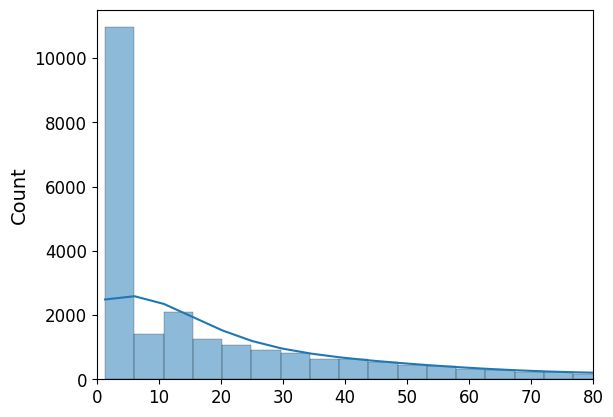

In [63]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(anomaly_scores, kde=True, bins=200) 
plt.xlim(0,80) 
plt.show()

In [75]:
train_tag=datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')

In [65]:
all_metrics_dfs = []
for thresh in range(10,50, 10):
        metrics, combined_df = networkEvaluator.evaluate(conf,model, data, all_nodes_df, 
                          thresh, load_tag, conf.artefact_path + "/metrics_train.csv", 
                          'F1 Score', 'AUC-PR')
                # Convert metrics dict to DataFrame (assuming keys are the metric names)
        metrics_df = pd.DataFrame([metrics])
        
        # Add a column for the threshold to track which metrics belong to which threshold
        metrics_df['threshold'] = thresh
        # Append the DataFrame to the list
        all_metrics_dfs.append(metrics_df)
# Concatenate all the DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

Evaluation Metrics:
alert_vol: 13980
Precision: 0.01044349070100143
Recall: 0.8795180722891566
F1 Score: 0.02064187756256185
Confusion Matrix: [[11979 13834]
 [   20   146]]
AUC-PR: 0.030290075731114353
AUC-ROC: 0.7917626030406832
Evaluation Metrics:
alert_vol: 10338
Precision: 0.012961888179531825
Recall: 0.8072289156626506
F1 Score: 0.025514089870525516
Confusion Matrix: [[15609 10204]
 [   32   134]]
AUC-PR: 0.030290075731114353
AUC-ROC: 0.7917626030406832
Evaluation Metrics:
alert_vol: 8221
Precision: 0.014840043790293151
Recall: 0.7349397590361446
F1 Score: 0.029092643376654344
Confusion Matrix: [[17714  8099]
 [   44   122]]
AUC-PR: 0.030290075731114353
AUC-ROC: 0.7917626030406832
Evaluation Metrics:
alert_vol: 6713
Precision: 0.01608818709965738
Recall: 0.6506024096385542
F1 Score: 0.03139991277802005
Confusion Matrix: [[19208  6605]
 [   58   108]]
AUC-PR: 0.030290075731114353
AUC-ROC: 0.7917626030406832


In [66]:
combined_metrics_df

,alert_vol,Precision,Recall,F1 Score,Confusion Matrix,AUC-PR,AUC-ROC,threshold
0,13980,0.010,0.880,0.021,"[[11979, 13834], [20, 146]]",0.030,0.792,10
1,10338,0.013,0.807,0.026,"[[15609, 10204], [32, 134]]",0.030,0.792,20
2,8221,0.015,0.735,0.029,"[[17714, 8099], [44, 122]]",0.030,0.792,30
3,6713,0.016,0.651,0.031,"[[19208, 6605], [58, 108]]",0.030,0.792,40


ROC-AUC: 0.79


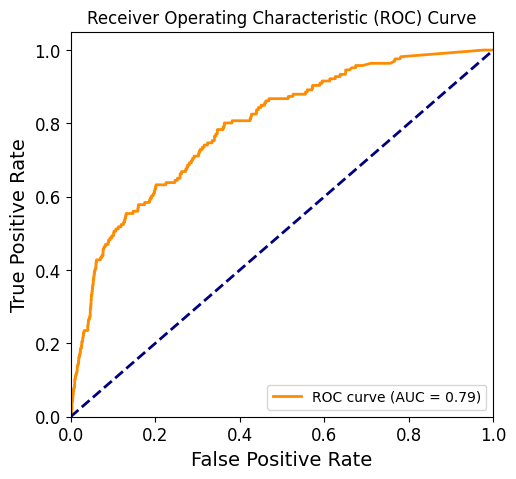

In [67]:
# ROC Curve
y_score=anomaly_scores
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")


# 4 Score Clusters

### 4.1 Anomaly Score

In [68]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

In [69]:
def generate_community_output(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)
        
        community_anomaly_scores = [anomaly_scores[node] for node in community]
        # avg_anomaly_score = sum(community_anomaly_scores) / len(community_anomaly_scores) if community_anomaly_scores else 0
    
        # Calculate metrics for anomaly scores within the community
        mean_score = np.mean(community_anomaly_scores)
        max_score = np.max(community_anomaly_scores)
        # sum_score = np.sum(community_anomaly_scores)

        edge_weights = [data.get('edge_weight', 0) for u, v, data in subgraph.edges(data=True)]
        total_weight = sum(edge_weights)
        avg_edge_weight = total_weight / len(edge_weights) if edge_weights else 0

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_exposure_id']for node, data in subgraph.nodes(data=True)]

        investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
        
        fraud_list = [data['fraud_flag'] for node, data in subgraph.nodes(data=True) if data['fraud_flag'] != 0]

        # # Clustering coefficient (average for nodes in the community)
        # avg_clustering = nx.average_clustering(subgraph)
        
        # # Conductance
        # conductance = compute_conductance(G, community)
        
        # # Density
        # density = nx.density(subgraph)
        
        # # Triangle count (sum of triangles in the community)
        # triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        # Calculate percentage of nodes with y == 1
        total_nodes = len(community)
        # y_count = sum(1 for node, data in subgraph.nodes(data=True) if data.get('y', 0) == 1)
        y_count =  len(investigation_list)
        y_percentage = (y_count / total_nodes * 100) if total_nodes > 0 else 0
        
        # Add metrics to the list
        community_metrics.append({
            'Community_id': i,
            'Nodes': node_list,
            'Claim Numbers': claim_list,
            'Average edge weight':avg_edge_weight,
            'Investigated count': len(investigation_list),
            'mean_anomaly_score': mean_score,
            'max_anomaly_score': max_score,
            'Fraud count':len(fraud_list),
            'Size': len(community),
            'investigation_rate': y_percentage # Optionally add community size
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [70]:
community_df = generate_community_output(G, filtered_communities)
community_df.head(10)

,Community_id,Nodes,Claim Numbers,Average edge weight,Investigated count,mean_anomaly_score,max_anomaly_score,Fraud count,Size,investigation_rate
0,0,"[16944, 21338, 8740, 9478]","[NWRTP2202655_1, NWRTP2401085_1, NWRTP2000179_...",0.102,1,178.849,230.443,0,4,25.000
1,1,"[21848, 9937, 2826, 22793]","[NWRTP2401598_1, NWRTP2001387_1, NWRTP1800898_...",0.097,0,69.868,171.005,0,4,0.000
2,2,"[22593, 19139, 14156, 16414]","[NWRTP2402348_1, NWRTP2302070_1, NWRTP2102678_...",0.082,0,155.362,278.458,0,4,0.000
3,3,"[1185, 17809, 17059, 16385]","[NWRND2200242_1, NWRTP2300733_1, NWRTP2202771_...",0.063,0,121.366,252.359,0,4,0.000
4,4,"[10955, 3859, 12260, 5067]","[NWRTP2002410_1, NWRTP1801940_1, NWRTP2100776_...",0.062,0,209.537,425.795,0,4,0.000
5,5,"[3041, 5189, 16108, 7388, 15804]","[NWRTP1801116_2, NWRTP1900133_1, NWRTP2201815_...",0.059,0,152.930,249.225,0,5,0.000
6,6,"[4691, 5789, 4547, 2767]","[NWRTP1802779_1, NWRTP1900742_1, NWRTP1802631_...",0.046,0,24.637,70.972,0,4,0.000
7,7,"[2919, 7342, 23312, 6394, 2459]","[NWRTP1800992_1, NWRTP1902315_1, NWRTP2403072_...",0.027,0,96.790,142.046,0,5,0.000
8,8,"[15397, 6374, 6218, 2874, 11291]","[NWRTP2201103_1, NWRTP1901333_1, NWRTP1901175_...",0.020,0,116.085,315.031,0,5,0.000
9,9,"[13696, 1220, 1221, 6597, 6247, 5896, 11174, 1...","[NWRTP2102216_1, NWRND2200277_1, NWRND2200278_...",0.013,0,135.195,448.628,0,16,0.000


In [95]:
# community_df.sort_values(by=['investigation_rate','rank_by_mean_anomaly_score'], 
#                          ascending=[False, True], inplace=True)
# community_df=community_df.reset_index(drop=True)
# community_df

In [71]:
# Create rank columns (lower rank = higher value)
community_df['rank_by_max_anomaly_score'] = community_df['max_anomaly_score'].rank(method='first', ascending=False).astype(int)
community_df['rank_by_mean_anomaly_score'] = community_df['mean_anomaly_score'].rank(method='first', ascending=False).astype(int)
community_df['rank_by_edge_weight'] = community_df['Average edge weight'].rank(method='first', ascending=False).astype(int)

community_df.sort_values(by=['rank_by_max_anomaly_score', 'rank_by_mean_anomaly_score', 'rank_by_edge_weight'], 
                         ascending=[True, True, True], inplace=True)
community_df=community_df.reset_index(drop=True)
community_df


,Community_id,Nodes,Claim Numbers,Average edge weight,Investigated count,mean_anomaly_score,max_anomaly_score,Fraud count,Size,investigation_rate,rank_by_max_anomaly_score,rank_by_mean_anomaly_score,rank_by_edge_weight
0,14,"[6885, 6722, 10700, 6437]","[NWRTP1901852_1, NWRTP1901687_1, NWRTP2002153_...",0.006,0,174.343,646.652,0,4,0.000,1,7,15
1,34,"[11688, 8265, 12499, 12548]","[NWRTP2100201_1, NWRTP1903246_1, NWRTP2101016_...",0.000,0,399.857,576.899,0,4,0.000,2,1,35
2,33,"[16645, 19336, 3337, 4364, 14733, 14734, 13711...","[NWRTP2202355_1, NWRTP2302270_1, NWRTP1801415_...",0.000,6,107.850,519.156,2,53,11.321,3,19,34
3,29,"[8384, 6914, 17475, 817, 1202, 10646, 24890]","[NWRTP1903368_1, NWRTP1901881_1, NWRTP2300397_...",0.000,1,232.211,457.814,0,7,14.286,4,2,30
4,24,"[8737, 15650, 16963, 5476, 13092, 17286, 24033...","[NWRTP2000176_1, NWRTP2201356_1, NWRTP2202674_...",0.001,1,156.485,453.459,0,17,5.882,5,10,25
5,9,"[13696, 1220, 1221, 6597, 6247, 5896, 11174, 1...","[NWRTP2102216_1, NWRND2200277_1, NWRND2200278_...",0.013,0,135.195,448.628,0,16,0.000,6,14,10
6,23,"[10603, 5326, 7410, 6966, 6269, 158]","[NWRTP2002056_1, NWRTP1900273_1, NWRTP1902383_...",0.001,1,91.802,445.729,1,6,16.667,7,22,24
7,16,"[513, 5281, 5447, 7783, 8428, 6926, 6162, 8115...","[NWRND2000024_2, NWRTP1900228_1, NWRTP1900396_...",0.005,0,159.015,443.505,0,11,0.000,8,9,17
8,4,"[10955, 3859, 12260, 5067]","[NWRTP2002410_1, NWRTP1801940_1, NWRTP2100776_...",0.062,0,209.537,425.795,0,4,0.000,9,4,5
9,13,"[13858, 25827, 12870, 9129, 12588, 3857, 10706...","[NWRTP2102380_1, NWRTP2502034_1, NWRTP2101388_...",0.006,0,170.757,419.118,0,9,0.000,10,8,14


In [72]:
df_final_output =df_output_merged.merge(community_df[['Community_id', 'rank_by_max_anomaly_score', 'investigation_rate']],
                                        on='Community_id', how='left')
df_final_output.head(10)

,Community_id,Claim exposure 1,Exposure 1 lodgement date,Exposure 1 status,Exposure 1 contact name,Exposure 1 contact number,Exposure 1 investigation flag,Claim exposure 2,Exposure 2 lodgement date,Exposure 2 status,Exposure 2 contact name,Exposure 2 contact number,Exposure 2 investigation flag,Relationship Type,Relationship Party,Party Contact,created date,rank_by_max_anomaly_score,investigation_rate
0,0,NWRTP2202655_1,2022-12-12,Open,Seokjin Ahn,0420559110,1,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0432167533,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...","(doctor: 0299957200, lawyer: 0297151771)",2025-09-05,23,25.000
1,0,NWRTP2202655_1,2022-12-12,Open,Seokjin Ahn,0420559110,1,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0415736871,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...","(doctor: 0299957200, lawyer: 0433573213)",2025-09-05,23,25.000
2,0,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0415736871,0,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0432167533,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...","(doctor: 0299957200, lawyer: 0433573213)",2025-09-05,23,25.000
3,0,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0415736871,0,NWRTP2000927_1,2020-05-06,Closed,Eun Park,0431373343,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...","(doctor: 0299957200, lawyer: 0433573213)",2025-09-05,23,25.000
4,0,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0432167533,0,NWRTP2000927_1,2020-05-06,Closed,Eun Park,0431373343,0,doc_lawyer,"(doctor: Subrata Banik, lawyer: Bareungil Lawy...","(doctor: 0299957200, lawyer: 0433573213)",2025-09-05,23,25.000
5,1,NWRTP2401598_1,2024-06-20,Closed,Emin Buyukkopru,0403182172,0,NWRTP1800898_1,2018-05-08,Closed,NADIR KAYA,0458962050,0,doc_lawyer,"(doctor: Nasrin Mostaphazadeh, lawyer: Sayan A...","(doctor: 0296469900, lawyer: 0296464405)",2025-09-05,26,0.000
6,1,NWRTP2401598_1,2024-06-20,Closed,Emin Buyukkopru,0403182172,0,NWRTP2001387_1,2020-07-09,Closed,MEHMET SOYLEMEZO,0405406013,0,doc_lawyer,"(doctor: Nasrin Mostaphazadeh, lawyer: Sayan A...","(doctor: 0296469900, lawyer: 0296464405)",2025-09-05,26,0.000
7,1,NWRTP2401598_1,2024-06-20,Closed,Emin Buyukkopru,0403182172,0,NWRTP2402548_1,2024-09-20,Open,Mehmet Kay,0414949699,0,doc_lawyer,"(doctor: Yasar Oner, lawyer: Gio Ctp)","(doctor: 0296469900, lawyer: 0296464405)",2025-09-05,26,0.000
8,1,NWRTP2001387_1,2020-07-09,Closed,MEHMET SOYLEMEZO,0405406013,0,NWRTP1800898_1,2018-05-08,Closed,NADIR KAYA,0458962050,0,doc_lawyer,"(doctor: Yasar Oner, lawyer: Sayan And Associa...","(doctor: 0296469900, lawyer: 0296464405)",2025-09-05,26,0.000
9,1,NWRTP2001387_1,2020-07-09,Closed,MEHMET SOYLEMEZO,0405406013,0,NWRTP2402548_1,2024-09-20,Open,Mehmet Kay,0414949699,0,doc_lawyer,"(doctor: Yasar Oner, lawyer: Gio Ctp)","(doctor: 0296469900, lawyer: 0296464405)",2025-09-05,26,0.000


In [73]:
table_schema='dl_aai_sqd_claim'
table_name ='ctp_syndicate_output'
sql(conf=conf, fn="write", sql=None, schema=table_schema, name=table_name, value=df_final_output, method='replace')
df_final_output.to_csv('ctp_community_output.csv', index=False)

In [99]:
global_avg_degree = sum(dict(G.degree()).values()) / len(G.nodes())
global_avg_degree


7.350261389096341

C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3601805149.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


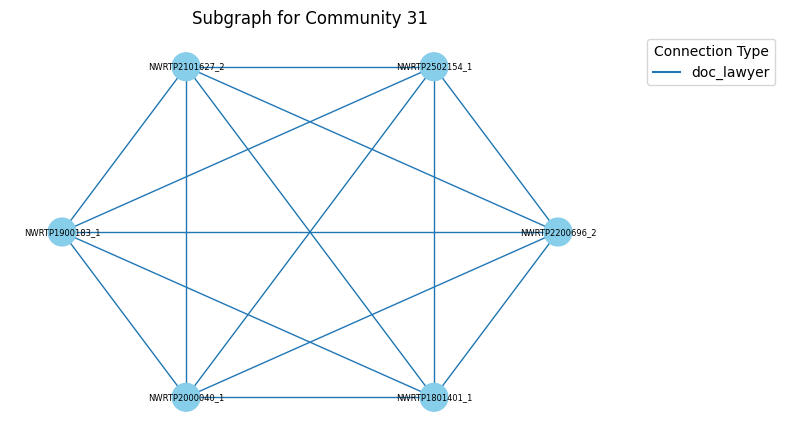

In [100]:
visualize_community(G, filtered_communities, 31)

# Bias Analysis

In [39]:
print('*' * 60)
print("Data query started ...")

create_date = datetime.datetime.now().strftime('%Y%m%d')
query = f"SELECT claim_number, claim_exposure_id, EXTRACT(YEAR FROM AGE(claim_lodgement_date, claimant_date_of_birth)) AS age, claimant_gender_name as gender FROM ctx.mv_cc_ci_claim_exposure_header_ext"
df_bias = sql( conf=conf, fn="get", sql=query)
print('*' * 60)
print("Data query finished")
df_bias

************************************************************
Data query started ...
************************************************************
Data query finished


,claim_number,claim_exposure_id,age,gender
0,NRA245812066,1,83.000,Male
1,RAV192024488,2,NaN,None
2,RAV213077216,1,62.000,Female
3,CGU213714010,1,NaN,None
4,CGU130057568,1,NaN,None
...,...,...,...,...
8543239,NRP224160436,2,NaN,None
8543240,CGU181332179,1,NaN,None
8543241,NRA235378478,1,74.000,Female
8543242,NRU224434614,1,33.000,Male


In [40]:
df_bias['claim_exposure_id']= df_bias['claim_number'] + '_'+ df_bias['claim_exposure_id'].astype(str)
df_bias = df_bias.drop(columns=['claim_number'])
df_bias

,claim_exposure_id,age,gender
0,NRA245812066_1,83.000,Male
1,RAV192024488_2,NaN,None
2,RAV213077216_1,62.000,Female
3,CGU213714010_1,NaN,None
4,CGU130057568_1,NaN,None
...,...,...,...
8543239,NRP224160436_2,NaN,None
8543240,CGU181332179_1,NaN,None
8543241,NRA235378478_1,74.000,Female
8543242,NRU224434614_1,33.000,Male


In [60]:
df_node_syndicate = all_nodes_df.reset_index()
df_node_syndicate = df_node_syndicate.merge(df_bias, on='claim_exposure_id', how='left')        
df_node_syndicate

,node_idx,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,...,off_work_minor_injury_flag,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult,age,gender
0,0,NWRTP1700088_1,2018-01-02,Closed,KATIE CLIFFORD,0400020783,12 HARRISON STREET CARDIFF NSW 2285,0,0,81.000,...,0,0,0,0,0,0,0,0,34.000,Female
1,1,NWRTP1700089_1,2018-01-02,Closed,TANIA RADOVIC,0432231500,34 WESTBROOK AVE WAHROONGA NSW 2076,0,0,72.000,...,1,0,0,0,0,0,0,0,19.000,Female
2,2,NWRTP1800001_1,2018-01-02,Closed,Gloria Rudder,0499401788,2031 Willi Willi Rd TEMAGOG NSW 2440,0,0,73.000,...,0,1,1,0,0,0,0,0,64.000,Female
3,3,NWRTP1800002_1,2018-01-02,Closed,JOSHUA FARR,0401579618,6 STOKE LANE CARCOAR NSW 2791,0,0,64.000,...,0,1,1,0,0,0,0,0,21.000,Male
4,4,NWRTP1800003_1,2018-01-02,Closed,JUAN CABREJOS,0427494778,13 THE CRESCENT HELENSBURGH NSW 2508,0,0,66.000,...,0,1,1,0,0,0,1,0,73.000,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31293,31293,NWRTP2502657_1,2025-09-25,Open,My Hoang,0411279665,152 Sackville St FAIRFIELD NSW 2165,0,0,0.000,...,0,0,0,0,0,0,0,0,56.000,Female
31294,31294,NWRTP2502658_1,2025-09-25,Open,Tess Walker,0400613000,6 Hilltop Gr CLIFTLEIGH NSW 2321,0,0,0.000,...,0,0,0,0,0,0,0,0,28.000,Female
31295,31295,NWRTP2502659_1,2025-09-25,Open,Rominder DODD,None,7 Alkoomie avenue Forestville NSW 2087,0,0,0.000,...,0,0,0,0,0,0,0,0,49.000,Male
31296,31296,NWRTP2502660_1,2025-09-25,Open,Fedoseeva Evgeniia,0490800862,1208 / 1 Australia Av SYDNEY OLYMPIC PARK NSW ...,0,0,0.000,...,0,0,0,0,0,0,0,0,38.000,Female


In [61]:
# Build set of all node indices that appear in any detected community
syndicate_nodes = set().union(*final_communities) if len(final_communities) > 0 else set()

# Create syndicate_flag: 1 if node_idx is in any community, else 0
df_node_syndicate['syndicate_flag'] = df_node_syndicate['node_idx'].isin(syndicate_nodes).astype(int)

# Quick check
print(df_node_syndicate['syndicate_flag'].value_counts())
df_node_syndicate.head()

0    28918
1     2380
Name: syndicate_flag, dtype: int64


,node_idx,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,...,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult,age,gender,syndicate_flag
0,0,NWRTP1700088_1,2018-01-02,Closed,KATIE CLIFFORD,0400020783,12 HARRISON STREET CARDIFF NSW 2285,0,0,81.000,...,0,0,0,0,0,0,0,34.000,Female,0
1,1,NWRTP1700089_1,2018-01-02,Closed,TANIA RADOVIC,0432231500,34 WESTBROOK AVE WAHROONGA NSW 2076,0,0,72.000,...,0,0,0,0,0,0,0,19.000,Female,0
2,2,NWRTP1800001_1,2018-01-02,Closed,Gloria Rudder,0499401788,2031 Willi Willi Rd TEMAGOG NSW 2440,0,0,73.000,...,1,1,0,0,0,0,0,64.000,Female,0
3,3,NWRTP1800002_1,2018-01-02,Closed,JOSHUA FARR,0401579618,6 STOKE LANE CARCOAR NSW 2791,0,0,64.000,...,1,1,0,0,0,0,0,21.000,Male,0
4,4,NWRTP1800003_1,2018-01-02,Closed,JUAN CABREJOS,0427494778,13 THE CRESCENT HELENSBURGH NSW 2508,0,0,66.000,...,1,1,0,0,0,1,0,73.000,Male,0


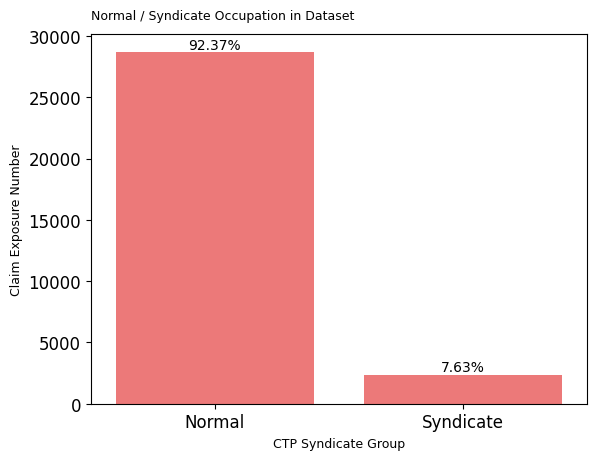

In [62]:
df_node_syndicate= df_node_syndicate[df_node_syndicate['gender']!='X - Non-specific']

# Assuming 'grouped' is already defined
grouped = df_node_syndicate.groupby(['syndicate_flag']).size().reset_index(name='counts')

# Create the plot
barplot = sns.barplot(data=grouped, x='syndicate_flag', y='counts', palette=['#FF6666'])

# Calculate the total count for calculating proportions
total = grouped['counts'].sum()

# Annotate each bar with the proportion
for p in barplot.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    barplot.annotate(percentage, (x, y), ha='center', va='bottom', color='black')

# Adding custom text aligned with the left of the chart
plt.text(0, 1.05, "Normal / Syndicate Occupation in Dataset", 
         ha='left', va='center', transform=barplot.transAxes, fontsize=9)

# Setting the axis labels
plt.xlabel('CTP Syndicate Group',fontsize=9)
plt.ylabel('Claim Exposure Number', fontsize=9)

# Setting custom labels for the x-axis ticks
barplot.set_xticklabels(['Normal', 'Syndicate'])

# Show the plot
plt.show()

### Group by Gender

In [94]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact

# Adjust column names if yours differ
gender_col = 'gender'
syndicate_col = 'syndicate_flag'

# Optional: drop missing/unknown categories explicitly
df = df_node_syndicate.copy()
df = df.dropna(subset=[gender_col, syndicate_col])
# If you have explicit unknown labels you want to exclude:
# df = df[~df[gender_col].isin(['Unknown', 'Prefer not to say'])]

# Ensure syndicate_flag is categorical (e.g., 0/1, True/False, or strings)
ct = pd.crosstab(df[gender_col], df[syndicate_col])  # rows: gender, cols: syndicate_flag
print(ct)


# For 2x2 tables, scipy applies Yates’ continuity correction by default.
# Set correction=False for large samples if you prefer the classical chi-square.
chi2, p, dof, expected = chi2_contingency(ct, correction=True)
print(f"Chi2 = {chi2:.4f}, p-value = {p:.4g}, dof = {dof}")
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print("Expected counts:\n", expected_df)

syndicate_flag      0     1
gender                     
Female          13923  1092
Male            14750  1281
Chi2 = 5.5614, p-value = 0.01836, dof = 1
Expected counts:
 syndicate_flag         0        1
gender                           
Female         13867.329 1147.671
Male           14805.671 1225.329


In [65]:

from scipy.stats import spearmanr

# Your lists
num_cols = [
    'days_of_minor_assess_to_lodgement',
    'pre_accident_weekly_earning',
    'amt_fitness_certificate',
    'late_treatment_days',
]
target_col = 'gender'  # change if your column is named differently

def ensure_binary_gender(series):
    """
    Attempts to binarize gender to {0,1}.
    Returns (encoded_series(float), mapping_dict).
    If >2 unique categories, uses one-vs-rest w/ most frequent category as '1'.
    """
    s = series.astype(str).str.strip().str.lower()
    mapping = {'female': 1, 'f': 1, 'woman': 1,
               'male': 0, 'm': 0, 'man': 0}
    encoded = s.map(mapping)

    # If mapping succeeded and is {0,1}
    if encoded.notna().any() and set(encoded.dropna().unique()).issubset({0, 1}):
        return encoded.astype(float), mapping

    # Fallback: one-vs-rest using most frequent category as 1
    vc = s.value_counts(dropna=True)
    if len(vc) >= 2:
        pos_class = vc.index[0]
        encoded = (s == pos_class).astype(float)
        return encoded, {pos_class: 1, 'other': 0}

    # If only one class or all NaN
    return pd.Series(np.nan, index=series.index), {}

def spearman_vs_gender(df, num_cols, target_col='gender'):
    """
    Computes Spearman's rank correlation between each numeric feature and gender (binary).
    Returns a DataFrame with columns: feature, n, spearman_corr, spearman_p.
    """
    # Encode gender
    g_enc, g_map = ensure_binary_gender(df[target_col])
    if g_enc.isna().all():
        raise ValueError("Unable to binarize gender. Provide explicit mapping (e.g., {'F':1, 'M':0}).")

    rows = []
    for col in num_cols:
        if col not in df.columns:
            rows.append({'feature': col, 'n': 0, 'spearman_corr': np.nan, 'spearman_p': np.nan})
            continue

        x = pd.to_numeric(df[col], errors='coerce')

        # Pairwise non-NA mask
        mask = x.notna() & g_enc.notna()
        x_clean = x[mask]
        g_clean = g_enc[mask]

        n = int(mask.sum())
        if n < 3 or len(np.unique(g_clean)) < 2:
            corr, p = np.nan, np.nan
        else:
            # Spearman correlation (ranks handle non-linear monotonic relationships)
            corr, p = spearmanr(x_clean, g_clean)

        rows.append({'feature': col, 'n': n, 'spearman_corr': corr, 'spearman_p': p})

    res = pd.DataFrame(rows).sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)
    # Optional: attach mapping info for audit
    res.attrs['gender_mapping'] = g_map
    return res

# ---- Usage example ----
df_spearman = spearman_vs_gender(df_node_syndicate, num_cols, target_col='gender')
df_spearman


,feature,n,spearman_corr,spearman_p
1,pre_accident_weekly_earning,31046,-0.092,0.000
2,amt_fitness_certificate,31046,-0.061,0.000
3,late_treatment_days,31046,-0.057,0.000
0,days_of_minor_assess_to_lodgement,31046,0.007,0.189


In [70]:

from scipy import stats
# --- Your flags ---
ohe_cols = [
    'not_fit_for_work_flag',
    'off_work_minor_injury_flag',
    'not_threshold_injury_flag',
    'suspacious_not_working_flag',
    'self_employed_flag',
    'cof_holiday_weekend_flag',
    'cof_issue_to_received_over_2m_flag',
    'rejected_pay_over_8_flag',
    'gp05_pay_exceed_gp_consult'
]
target_col = 'gender'  # change if the gender column name differs

def ensure_binary_gender(series):
    """
    Binarize gender to {0,1}. Returns (encoded_series(float), mapping_dict).
    Uses common mappings; if multi-class, defaults to one-vs-rest with the most
    frequent category as 1.
    """
    s = series.astype(str).str.strip().str.lower()
    mapping = {'female': 1, 'f': 1, 'woman': 1,
               'male': 0, 'm': 0, 'man': 0}
    encoded = s.map(mapping)

    # If successful and within {0,1}
    if encoded.notna().any() and set(encoded.dropna().unique()).issubset({0, 1}):
        return encoded.astype(float), mapping

    # Fallback: one-vs-rest using most frequent category as 1
    vc = s.value_counts(dropna=True)
    if len(vc) >= 2:
        pos_class = vc.index[0]
        encoded = (s == pos_class).astype(float)
        return encoded, {pos_class: 1, 'other': 0}

    # If only one class or all NaN
    return pd.Series(np.nan, index=series.index), {}

def phi_coefficient_from_table(table_2x2):
    """Compute phi coefficient from a 2x2 contingency table [[a,b],[c,d]]."""
    a, b = table_2x2[0]
    c, d = table_2x2[1]
    n = a + b + c + d
    numerator = (a * d) - (b * c)
    denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    if denom == 0:
        return np.nan
    return numerator / denom

def chi_square_flags_vs_gender(df, ohe_cols, target_col='gender', correction=False):
    """
    Iteratively run chi-square tests between each binary flag and gender.
    Returns a DataFrame with columns:
      feature, n, chi2_stat, chi2_p, phi_corr, prop_gender1_feature1, prop_gender0_feature1,
      a,b,c,d (cell counts for audit)
    """
    # Encode gender
    g_enc, g_map = ensure_binary_gender(df[target_col])
    if g_enc.isna().all():
        raise ValueError("Unable to binarize gender. Provide explicit mapping (e.g., {'F':1, 'M':0}).")

    rows = []

    for col in ohe_cols:
        if col not in df.columns:
            rows.append({
                'feature': col, 'n': 0, 'chi2_stat': np.nan, 'chi2_p': np.nan, 'phi_corr': np.nan,
                'prop_gender1_feature1': np.nan, 'prop_gender0_feature1': np.nan,
                'a': np.nan, 'b': np.nan, 'c': np.nan, 'd': np.nan
            })
            continue

        # Ensure binary 0/1 (non-zero -> 1, zero -> 0)
        b = pd.to_numeric(df[col], errors='coerce')
        b = b.apply(lambda v: np.nan if pd.isna(v) else (1 if float(v) != 0.0 else 0)).astype('float')

        # Pairwise non-NA
        mask = b.notna() & g_enc.notna()
        b_clean = b[mask].astype(int)
        g_clean = g_enc[mask].astype(int)
        n = int(mask.sum())

        if n < 5 or len(np.unique(b_clean)) < 2 or len(np.unique(g_clean)) < 2:
            rows.append({
                'feature': col, 'n': n, 'chi2_stat': np.nan, 'chi2_p': np.nan, 'phi_corr': np.nan,
                'prop_gender1_feature1': np.nan, 'prop_gender0_feature1': np.nan,
                'a': np.nan, 'b': np.nan, 'c': np.nan, 'd': np.nan
            })
            continue

        # Contingency table: rows=gender(0/1), cols=flag(0/1)
        ct = pd.crosstab(g_clean, b_clean)
        # Ensure full 2x2 (fill missing levels with zeros)
        for val in [0, 1]:
            if val not in ct.index:
                ct.loc[val] = [0, 0] if 0 in ct.columns else []
            if val not in ct.columns:
                ct[val] = 0
        ct = ct.sort_index().sort_index(axis=1)

        a = int(ct.loc[0, 0])  # gender=0, flag=0
        b_ = int(ct.loc[0, 1]) # gender=0, flag=1
        c = int(ct.loc[1, 0])  # gender=1, flag=0
        d = int(ct.loc[1, 1])  # gender=1, flag=1

        # Chi-square test (set correction=True for Yates if desired)
        chi2_stat, chi2_p, _, _ = stats.chi2_contingency(ct, correction=correction)

        # Phi coefficient (effect size for 2x2)
        phi = phi_coefficient_from_table([[a, b_], [c, d]])

        # Proportions of flag=1 within each gender
        prop_g1 = d / (c + d) if (c + d) > 0 else np.nan
        prop_g0 = b_ / (a + b_) if (a + b_) > 0 else np.nan

        rows.append({
            'feature': col,
            'n': n,
            'chi2_stat': chi2_stat,
            'chi2_p': chi2_p,
            'phi_corr': phi,
        #     'prop_gender1_feature1': prop_g1,
        #     'prop_gender0_feature1': prop_g0,
        #     'a': a, 'b': b_, 'c': c, 'd': d
        })

    res = pd.DataFrame(rows).sort_values(by='phi_corr', key=lambda s: s.abs(), ascending=False)
    # Attach mapping for audit trail
    res.attrs['gender_mapping'] = g_map
    return res

# ---- Usage example ----
df_chi = chi_square_flags_vs_gender(df_node_syndicate, ohe_cols, target_col='gender', correction=False)
df_chi


,feature,n,chi2_stat,chi2_p,phi_corr
2,not_threshold_injury_flag,31046,691.907,0.000,-0.149
4,self_employed_flag,31046,205.221,0.000,-0.081
0,not_fit_for_work_flag,31046,124.560,0.000,-0.063
1,off_work_minor_injury_flag,31046,95.036,0.000,0.055
5,cof_holiday_weekend_flag,31046,19.563,0.000,-0.025
6,cof_issue_to_received_over_2m_flag,31046,11.451,0.001,-0.019
3,suspacious_not_working_flag,31046,9.590,0.002,-0.018
7,rejected_pay_over_8_flag,31046,3.869,0.049,-0.011
8,gp05_pay_exceed_gp_consult,31046,0.609,0.435,-0.004


In [71]:
cols=['investigation_flag','fraud_flag', 'syndicate_flag']
df_chi = chi_square_flags_vs_gender(df_node_syndicate, cols, target_col='gender', correction=False)
df_chi

,feature,n,chi2_stat,chi2_p,phi_corr
0,investigation_flag,31046,27.445,0.000,-0.030
1,fraud_flag,31046,5.668,0.017,-0.014
2,syndicate_flag,31046,5.663,0.017,-0.014


C:\Users\s745998\AppData\Local\Temp\ipykernel_28324\866655771.py:40: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  plt.legend(title='Syndicate Flag', labels=['Normal', 'Syndicate'], loc='upper right', handles=barplot.legend_.legendHandles)


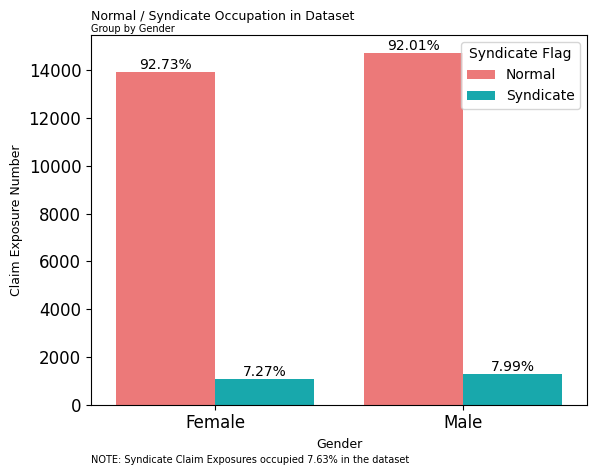

In [72]:
# Grouping data
grouped = df_node_syndicate.groupby(['gender', 'syndicate_flag']).size().reset_index(name='counts')

# Calculate total counts for each gender to compute proportions
total_counts = grouped.groupby('gender')['counts'].transform('sum')
grouped['proportion'] = grouped['counts'] / total_counts

# Specifying the color palette
color_palette = ['#FF6666', '#00bfc4']  # Red for 'Normal(0)', Cyan for 'Abnormal(1)'

# Plotting
barplot = sns.barplot(data=grouped, x='gender', y='counts', hue='syndicate_flag', palette=color_palette)

# Annotating with proportions
bar_list = [0, 2, 1, 3]
for i, bar in enumerate(barplot.patches):
    height = bar.get_height()
    barplot.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=height,
        s=f"{grouped['proportion'][bar_list[i]]:.2%}",
        ha='center',
        va='bottom'
    )

# Adding title and subtitle
plt.text(0, 1.05, "Normal / Syndicate Occupation in Dataset", 
         ha='left', va='center', transform=barplot.transAxes, fontsize=9)
plt.text(0, 1.015, "Group by Gender", 
         ha='left', va='center', transform=barplot.transAxes, fontsize=7)

plt.text(0, -0.15, "NOTE: Syndicate Claim Exposures occupied 7.63% in the dataset", 
         ha='left', va='center', transform=barplot.transAxes, fontsize=7)

# Adjusting labels and titles
plt.xlabel('Gender', fontsize=9)
plt.ylabel('Claim Exposure Number', fontsize=9)

# Fixing the legend to match the bar colors
plt.legend(title='Syndicate Flag', labels=['Normal', 'Syndicate'], loc='upper right', handles=barplot.legend_.legendHandles)



### Group by Age

In [ ]:
# Number of groups to split into
num_groups = 6

# Use qcut to split the 'age' column into equal-sized groups
age_bins = pd.qcut(df_node_syndicate['age'], q=num_groups)

# Create readable labels from bin intervals
labels = [f"{int(interval.left)}-{int(interval.right)}" for interval in age_bins.cat.categories]

# Map each bin to its label
bin_to_label = dict(zip(age_bins.cat.categories, labels))

# Avoid SettingWithCopyWarning by copying the dataframe
df_node_syndicate = df_node_syndicate.copy()

# Assign the labeled age groups
df_node_syndicate['age_group'] = age_bins.map(bin_to_label)
df_node_syndicate['age_group'].value_counts()


0-24      5400
41-51     5209
32-41     5187
62-122    5164
24-32     5161
51-62     4935
Name: age_group, dtype: int64

In [105]:
# # Define the bins for age groups
# bins = [16, 34, 52, 69, 87, 105]

# # Labels for the age groups
# labels = ['17-34', '35-52', '53-69', '70-87', '88-105']

# # Create a new column for age groups
# df_node_syndicate['age_group'] = pd.cut(df_node_syndicate['age'], bins=bins, labels=labels, right=True)

# Now you can group by age_group (and any other column if needed)
grouped_age = df_node_syndicate.groupby('age_group').size().reset_index(name='counts')

# Display the grouped data
print(grouped_age)

  age_group  counts
0      0-24    5400
1     24-32    5161
2     32-41    5187
3     41-51    5209
4     51-62    4935
5    62-122    5164


In [106]:
# Grouping by age_group and any other relevant column if needed (for example, anomaly flag)
grouped_age = df_node_syndicate.groupby(['age_group', 'syndicate_flag']).size().reset_index(name='counts')

# Calculate total counts for each age group to compute proportions
total_counts_age = grouped_age.groupby('age_group')['counts'].transform('sum')
grouped_age['proportion'] = grouped_age['counts'] / total_counts_age
grouped_age

,age_group,syndicate_flag,counts,proportion
0,0-24,0,4930,0.913
1,0-24,1,470,0.087
2,24-32,0,4761,0.922
3,24-32,1,400,0.078
4,32-41,0,4778,0.921
5,32-41,1,409,0.079
6,41-51,0,4790,0.920
7,41-51,1,419,0.080
8,51-62,0,4540,0.920
9,51-62,1,395,0.080


C:\Users\s745998\AppData\Local\Temp\ipykernel_28324\1070459414.py:29: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  plt.legend(title='Syndicate Flag', labels=['Normal', 'Syndicate'], loc='center right', handles=barplot_age.legend_.legendHandles)


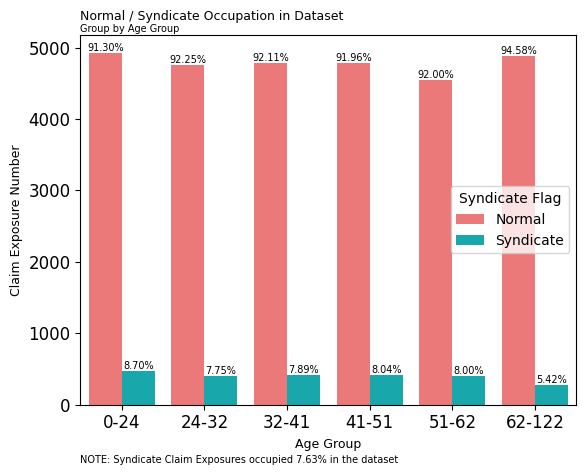

In [111]:
# Plotting
barplot_age = sns.barplot(data=grouped_age, x='age_group', y='counts', hue='syndicate_flag', palette=['#FF6666', '#00bfc4'])

# Annotating with proportions
bar_list = [0, 2, 4, 6, 8, 10, 1, 3, 5, 7, 9,11]
# bar_list = [0, 2, 4, 6, 8, 1, 3, 5, 7, 9]
for i, bar in enumerate(barplot_age.patches):
    height = bar.get_height()
    barplot_age.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=height,
        s=f"{grouped_age['proportion'][bar_list[i]]:.2%}",  # Formatting the proportion as a percentage
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=7
    )

# Adding titles and labels
plt.text(0, 1.05, "Normal / Syndicate Occupation in Dataset", 
         ha='left', va='center', transform=barplot_age.transAxes, fontsize=9)
plt.text(0, 1.015, "Group by Age Group", 
         ha='left', va='center', transform=barplot_age.transAxes, fontsize=7)
plt.text(0, -0.15, "NOTE: Syndicate Claim Exposures occupied 7.63% in the dataset", 
         ha='left', va='center', transform=barplot_age.transAxes, fontsize=7)
plt.xlabel('Age Group', fontsize=9)
plt.ylabel('Claim Exposure Number', fontsize=9)

# Fixing the legend to match the bar colors
plt.legend(title='Syndicate Flag', labels=['Normal', 'Syndicate'], loc='center right', handles=barplot_age.legend_.legendHandles)
plt.show()

In [112]:
# correlation analysis on age and continous variable
df_spearman = spearman_vs_gender(df_node_syndicate, num_cols, target_col='age_group')
df_spearman

,feature,n,spearman_corr,spearman_p
1,pre_accident_weekly_earning,31094,-0.053,0.000
3,late_treatment_days,31094,-0.048,0.000
2,amt_fitness_certificate,31094,-0.047,0.000
0,days_of_minor_assess_to_lodgement,31094,-0.005,0.369


In [113]:
# correlation analysis on age group and categorical variable
df_chi = chi_square_flags_vs_gender(df_node_syndicate, ohe_cols, target_col='age_group', correction=False)
df_chi

,feature,n,chi2_stat,chi2_p,phi_corr
4,self_employed_flag,31094,140.847,0.000,-0.067
1,off_work_minor_injury_flag,31094,56.516,0.000,-0.043
0,not_fit_for_work_flag,31094,44.238,0.000,-0.038
7,rejected_pay_over_8_flag,31094,13.274,0.000,-0.021
3,suspacious_not_working_flag,31094,12.623,0.000,-0.020
5,cof_holiday_weekend_flag,31094,6.372,0.012,-0.014
6,cof_issue_to_received_over_2m_flag,31094,5.949,0.015,-0.014
8,gp05_pay_exceed_gp_consult,31094,0.921,0.337,-0.005
2,not_threshold_injury_flag,31094,0.001,0.975,0.000


In [114]:
df_chi = chi_square_flags_vs_gender(df_node_syndicate, cols, target_col='age_group', correction=False)
df_chi

,feature,n,chi2_stat,chi2_p,phi_corr
2,syndicate_flag,31094,10.653,0.001,0.019
0,investigation_flag,31094,1.352,0.245,-0.007
1,fraud_flag,31094,0.988,0.320,-0.006
